# Import libraries

In [1]:
import pandas as pd
import numpy as np
import plotly.graph_objs as go
from plotly.subplots import make_subplots
from plotly import express as px
import plotly.figure_factory as ff

from statsmodels.stats.outliers_influence import variance_inflation_factor
from scipy.stats import chi2
from sklearn.preprocessing import OrdinalEncoder, MinMaxScaler
from sklearn.feature_selection import mutual_info_regression
from sklearn.ensemble import IsolationForest
from umap import UMAP

from sklearn.linear_model import LinearRegression
import sklearn
from sklearn.model_selection import KFold, train_test_split
from sklearn.metrics import *

from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from sklearn.ensemble import HistGradientBoostingRegressor
from catboost import CatBoostRegressor
from sklearn.linear_model import LinearRegression, ElasticNetCV, RidgeCV, LassoCV
from sklearn.ensemble import StackingRegressor
import optuna

# !pip install "kaleido==0.1.0.post1"

SEED = 17
compare_metric_name = "RMSE"
N_TRIALS = 100

# Utility functions

In [2]:
def base_information(data):
    df =  pd.DataFrame(data.dtypes, columns=['dtypes'])
    df['Number of missing values'] = data.isna().sum()
    df['Percentage of missing values'] = data.isna().sum()/data.shape[0]
    df['Unique values'] = data.nunique().values
    df['Count'] = data.count().values
    return df.style.background_gradient(cmap='Blues')

In [3]:
def perform_cv(X: pd.DataFrame, y: pd.Series, algorithm: object, cv: sklearn.model_selection = KFold(n_splits=5, shuffle=True, random_state=SEED), metric: sklearn.metrics = root_mean_squared_error) -> tuple[list[float], list[float]]:
    """
    Perform cross-validation and return list of scores
    
    Args:
        X (pd.DataFrame): input data
        y (pd.Series): target data
        algorithm (Any): algorithm to use for training and prediction
        cv (sklearn.model_selection, default=KFold(n_splits=5, shuffle=True, random_state=SEED)): cross-validation strategy
        metric (sklearn.metrics, default=root_mean_squared_error): metric to use for evaluation
    
    Returns:
        Tuple[List[float], List[float]]: Tuple of lists of train and validation scores
    """
    train_scores, validation_scores = [], []
    for train_idx, val_idx in cv.split(X, y):
        X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
        y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]
        algorithm.fit(X_train, y_train)
        y_train_pred = algorithm.predict(X_train)
        y_val_pred = algorithm.predict(X_val)
        train_scores.append(metric(y_train, y_train_pred))
        validation_scores.append(metric(y_val, y_val_pred))
    return train_scores, validation_scores

In [4]:
class Plots:
    def __init__(self):
        self.quantiles_dict = {"Min": 0, "Q1": 0.25, "Med": 0.5, "Q3": 0.75, "Max": 1}

    def check_data(self, data):
        if not isinstance(data, pd.DataFrame) and not isinstance(data, pd.Series) and not isinstance(data, np.ndarray):
            raise TypeError('Wrong type of data. It should be pandas DataFrame, pandas Series, numpy array')
        data = np.array(data)
        data = data[~np.isnan(data)]
        if(data.ndim == 2):
            data = data.squeeze()
        return data
    
    def check_2d_data(self, data):
        if not isinstance(data, pd.DataFrame) and not isinstance(data, pd.Series) and not isinstance(data, np.ndarray):
            raise TypeError('Wrong type of data. It should be pandas DataFrame, pandas Series, numpy array')
        return np.array(data)
    
    def histogram_and_box_plot(self, data, name="", annotations=True, bin_size=1):
        data = self.check_data(data=data)
        fig = make_subplots(rows=1, cols=2, specs=[[{"type": "histogram"}, {"type": "box"}]])
        fig.add_trace(go.Box(y=data, name='', marker=dict(color="rgb(48,70,116)"), showlegend=False), row=1, col=1)
        fig.add_trace(go.Histogram(x=data, marker=dict(color="rgb(48,70,116)"), showlegend=False, xbins=dict(size=bin_size)), row=1, col=2)
        if type(annotations) == list:
            for x in annotations:
                fig.add_annotation(x=0.4, y=np.quantile(data, self.quantiles_dict[x]), text=x + ": " + str(np.round(np.quantile(data, self.quantiles_dict[x]), 3)), showarrow=False)
        elif type(annotations) == bool:
            if annotations:
                for key, value in self.quantiles_dict.items():
                    fig.add_annotation(x=0.4, y=np.quantile(data, value), text=key + ": " + str(np.round(np.quantile(data, value), 3)), showarrow=False)
        fig.update_layout(template="simple_white", width=1600, height=800, title=f"<b>{name.title()} distribution<b>", title_x=0.5, font=dict(family="Times New Roman",size=16,color="Black"))
        fig.show("png")
    
    def histogram_boxplot_linear_regression(self, data, feature, target, name="", annotations=True, bin_size=1):
        model = LinearRegression()
        no_nan_indices = ~data[feature].isna()
        model.fit(data[no_nan_indices][feature].values.reshape(-1, 1), data[no_nan_indices][target])
        predictions = model.predict(data[no_nan_indices][feature].values.reshape(-1, 1))
        fig = make_subplots(rows=1, cols=3, specs=[[{"type": "histogram"}, {"type": "box"}, {"type": "scatter"}]])
        fig.add_trace(go.Box(y=data[no_nan_indices][feature], name='', marker=dict(color="rgb(48,70,116)"), showlegend=False), row=1, col=1)
        fig.add_trace(go.Histogram(x=data[no_nan_indices][feature], marker=dict(color="rgb(48,70,116)"), showlegend=False, xbins=dict(size=bin_size)), row=1, col=2)
        fig.add_trace(go.Scatter(x=data[no_nan_indices][feature], y=data[no_nan_indices][target], mode='markers', marker=dict(color="lightblue"), name='Real values', showlegend=False), row=1, col=3)
        fig.add_trace(go.Scatter(x=data[no_nan_indices][feature], y=predictions, mode='lines', line_color="green", name=feature, showlegend=False), row=1, col=3)
        fig.update_xaxes(title_text=feature, row=1, col=3)
        fig.update_yaxes(title_text=f"{target}", row=1, col=3)
        if type(annotations) == list:
            for x in annotations:
                fig.add_annotation(x=0.4, y=np.quantile(data[no_nan_indices][feature], self.quantiles_dict[x]), text=x + ": " + str(np.round(np.quantile(data[no_nan_indices][feature], self.quantiles_dict[x]), 3)), showarrow=False)
        elif type(annotations) == bool:
            if annotations:
                for key, value in self.quantiles_dict.items():
                    fig.add_annotation(x=0.4, y=np.quantile(data[no_nan_indices][feature], value), text=key + ": " + str(np.round(np.quantile(data[no_nan_indices][feature], value), 3)), showarrow=False)
        fig.update_layout(template="simple_white", width=2000, height=800, title=f"<b>{name.title()} distribution<b>", title_x=0.5, font=dict(family="Times New Roman",size=16,color="Black"))
        fig.show("png")
    
    def boxplot_by_categorical(self, data, categorical, target, name=""):
        data_copy = data.copy()
        data_copy.reset_index(drop=True, inplace=True)
        labels, frequency = np.array(data_copy[categorical].value_counts().index), np.array(data_copy[categorical].value_counts().values)
        sorted_indices = np.argsort(frequency)[::-1]
        labels = labels[sorted_indices]
        frequency = frequency[sorted_indices]
        colors = px.colors.qualitative.Dark24*20
        fig = go.Figure()
        for color_idx, category in enumerate(labels):
            indices = list(np.where(data_copy[categorical]==category)[0])
            grouped_data = list(data_copy[target][indices])
            fig.add_trace(go.Box(y=grouped_data, name=str(category), marker=dict(color=colors[color_idx]), showlegend=False))
        fig.update_layout(template="simple_white", width=1600, height=800, title=f"<b>{name.title()} distribution<b>", title_x=0.5, font=dict(family="Times New Roman",size=16,color="Black"))
        fig.update_yaxes(title_text=f"{target}", title_font=dict(size=16, color="Black"))
        fig.show("png")
    
    def pie_boxplot_by_categorical(self, data, categorical, target, name=""):
        data_copy = data.copy()
        data_copy.reset_index(drop=True, inplace=True)
        labels, frequency = np.array(data_copy[categorical].value_counts().index), np.array(data_copy[categorical].value_counts().values)
        sorted_indices = np.argsort(frequency)[::-1]
        labels = labels[sorted_indices]
        frequency = frequency[sorted_indices]
        colors = px.colors.qualitative.Dark24
        rows, columns = 1, 2
        fig = make_subplots(rows=rows, cols=columns, specs=[[{"type": "pie"}, {"type": "bar"}] for i in range(0, rows)])
        fig.add_trace(go.Pie(values=frequency, labels=labels, showlegend=True, textinfo='value+percent', hole=0.3, marker=dict(line=dict(color='black', width=2), colors=colors)), row=1, col=1)
        for color_idx, category in enumerate(labels):
            indices = list(np.where(data_copy[categorical]==category)[0])
            grouped_data = list(data_copy[target][indices])
            fig.add_trace(go.Box(y=grouped_data, name=str(category), marker=dict(color=colors[color_idx]), showlegend=False))
        fig.update_layout(template="simple_white", width=1600, height=800, title=f"<b>{name.title()} distribution<b>", title_x=0.5, font=dict(family="Times New Roman",size=16,color="Black"))
        fig.show("png")
    
    def correlation_plot(self, data, features_names, method="spearman"):
        data = self.check_2d_data(data=data)
        data = pd.DataFrame(data, columns=features_names)
        corr = np.round(data[data.columns.tolist()].corr(method=method), 3)
        mask = np.triu(np.ones_like(corr, dtype=bool))
        data_mask = corr.mask(mask)
        fig = ff.create_annotated_heatmap(z=data_mask.to_numpy(), x=data_mask.columns.tolist(), y=data_mask.columns.tolist(), colorscale=px.colors.diverging.RdBu,hoverinfo="none", showscale=True, ygap=1, xgap=1)
        fig.update_xaxes(side="bottom")
        fig.update_layout(width=1000, height=1000, xaxis_showgrid=False,yaxis_showgrid=False,xaxis_zeroline=False,yaxis_zeroline=False,yaxis_autorange='reversed',template='plotly_white',font=dict(family="Times New Roman",size=20,color="Black"))
        for i in range(len(fig.layout.annotations)):
            if fig.layout.annotations[i].text == 'nan':
                fig.layout.annotations[i].text = ""
        fig.show("png")
    
    def scatter_plot(self, data, hue, hue_name, name=""):
        data = np.array(data)
        hue = np.array(hue).squeeze()
        fig = go.Figure()
        unique_hues = np.unique(hue)
        for unique_hue in unique_hues:
            fig.add_trace(go.Scatter(x=data[hue == unique_hue, 0], y=data[hue == unique_hue, 1], mode='markers', marker=dict(showscale=False), name=str(unique_hue)))
        fig.update_xaxes(title_text="Component 1")
        fig.update_yaxes(title_text="Component 2")
        fig.update_layout(template="simple_white", width=1000, height=1000, title=f"<b>{name}<b>", title_x=0.5, font=dict(family="Times New Roman", size=26, color="Black"), legend_title_text=hue_name, legend_title_font=dict(size=26, color="Black"), legend_font=dict(size=20, color="Black"))
        fig.show("png")

    def homoscedacity_plot(self, y_true, y_pred, metric="RMSE"):
        metrics = { "MSE": mean_squared_error(y_true, y_pred),
                "RMSE": root_mean_squared_error(y_true, y_pred),
                "MAE": mean_absolute_error(y_true, y_pred)}
        if metric not in metrics:
            raise ValueError('Unsupported metric: {}'.format(metric))
        eval_metric = np.round(metrics[metric], 5)
        y_true = np.array(y_true)
        y_pred = np.array(y_pred)
        residuals = y_true - y_pred
        fig = px.scatter(x=y_pred, y=residuals, labels={"x": "Fitted values",  "y": "Residuals"})
        fig.add_shape(type="line", line_color="red", line_width=2, opacity=0.5, line_dash="dash",x0=0, x1=1, xref="paper", y0=0, y1=0, yref="y")
        fig.update_layout(template="simple_white", width=1200, height=1000, title=f"<b>Homoscedacity plot ({metric.upper()}: {eval_metric:.4f})<b>", title_x=0.5, xaxis_title="Fitted values", yaxis_title="Residuals", font=dict(family="Times New Roman",size=16,color="Black"))
        fig.show("png")
    
    def true_vs_fitted_plot(self, y_true, y_pred, metric="RMSE"):
        metrics = { "MSE": mean_squared_error(y_true, y_pred),
                "RMSE": root_mean_squared_error(y_true, y_pred),
                "MAE": mean_absolute_error(y_true, y_pred)}
        if metric not in metrics:
            raise ValueError('Unsupported metric: {}'.format(metric))
        eval_metric = np.round(metrics[metric], 5)
        y_true = np.array(y_true)
        y_pred = np.array(y_pred)
        fig = px.scatter(x=y_pred, y=y_true, labels={"x": "Fitted values",  "y": "True values"}, trendline="ols", trendline_color_override="green")
        fig.data[1].line.width = 8
        fig.update_layout(template="simple_white", width=1200, height=1000, xaxis_title="Fitted values", yaxis_title="True values", title=f"<b>True vs Fitted plot ({metric.upper()}: {eval_metric:.4f})<b>", title_x=0.5, font=dict(family="Times New Roman",size=16,color="Black"))
        fig.update_xaxes(range=[np.min(y_pred) - 0.01 * np.min(y_pred), np.max(y_pred) + 0.01 * np.max(y_pred)])
        fig.update_yaxes(range=[np.min(y_true) - 0.01 * np.min(y_true), np.max(y_true) + 0.01 * np.max(y_true)])
        fig.show("png")
    
plots = Plots()

# Load dataset

In [5]:
train_data = pd.read_csv('input/train.csv')
test_data = pd.read_csv('input/test.csv')
train_data = train_data[:10000]
train_data

,id,Podcast_Name,Episode_Title,Episode_Length_minutes,Genre,Host_Popularity_percentage,Publication_Day,Publication_Time,Guest_Popularity_percentage,Number_of_Ads,Episode_Sentiment,Listening_Time_minutes
0,0,Mystery Matters,Episode 98,NaN,True Crime,74.81,Thursday,Night,NaN,0.0,Positive,31.41998
1,1,Joke Junction,Episode 26,119.80,Comedy,66.95,Saturday,Afternoon,75.95,2.0,Negative,88.01241
2,2,Study Sessions,Episode 16,73.90,Education,69.97,Tuesday,Evening,8.97,0.0,Negative,44.92531
3,3,Digital Digest,Episode 45,67.17,Technology,57.22,Monday,Morning,78.70,2.0,Positive,46.27824
4,4,Mind & Body,Episode 86,110.51,Health,80.07,Monday,Afternoon,58.68,3.0,Neutral,75.61031
...,...,...,...,...,...,...,...,...,...,...,...,...
9995,9995,Money Matters,Episode 49,100.09,Business,95.05,Thursday,Afternoon,29.69,1.0,Positive,68.72770
9996,9996,Style Guide,Episode 58,107.40,Lifestyle,43.68,Wednesday,Evening,99.26,3.0,Neutral,85.91000
9997,9997,Funny Folks,Episode 12,23.38,Comedy,99.43,Monday,Morning,NaN,2.0,Negative,14.46127
9998,9998,Health Hour,Episode 88,33.61,Health,68.36,Saturday,Afternoon,NaN,2.0,Neutral,12.97000


In [6]:
base_information(train_data)

,dtypes,Number of missing values,Percentage of missing values,Unique values,Count
id,int64,0,0.000000,10000,10000
Podcast_Name,object,0,0.000000,48,10000
Episode_Title,object,0,0.000000,100,10000
Episode_Length_minutes,float64,1175,0.117500,5320,8825
Genre,object,0,0.000000,10,10000
Host_Popularity_percentage,float64,0,0.000000,5099,10000
Publication_Day,object,0,0.000000,7,10000
Publication_Time,object,0,0.000000,4,10000
Guest_Popularity_percentage,float64,1992,0.199200,4950,8008
Number_of_Ads,float64,0,0.000000,4,10000


In [7]:
base_information(test_data)

,dtypes,Number of missing values,Percentage of missing values,Unique values,Count
id,int64,0,0.000000,250000,250000
Podcast_Name,object,0,0.000000,48,250000
Episode_Title,object,0,0.000000,100,250000
Episode_Length_minutes,float64,28736,0.114944,11631,221264
Genre,object,0,0.000000,10,250000
Host_Popularity_percentage,float64,0,0.000000,8010,250000
Publication_Day,object,0,0.000000,7,250000
Publication_Time,object,0,0.000000,4,250000
Guest_Popularity_percentage,float64,48832,0.195328,9961,201168
Number_of_Ads,float64,0,0.000000,6,250000


# Initial cleaning

In [8]:
def initial_columns_removal(df: pd.DataFrame) -> pd.DataFrame:
    """
    Remove features that are not useful for the model:
        - 1 unique value (variance = 0)
        - all missing values
        - duplicated columns
    
    Args:
        df (pd.DataFrame): DataFrame to be cleaned.
    
    Returns:
        pd.DataFrame: Cleaned DataFrame.
    """
    number_of_columns_before = df.shape[1]
    df = df.loc[:, df.nunique() > 1]
    df = df.dropna(axis=1, how='all')
    df = df.loc[:, ~df.columns.duplicated()]
    print(f"Removed {number_of_columns_before - df.shape[1]} columns.")
    return df.reset_index(drop=True)

train_data = initial_columns_removal(train_data)

Removed 0 columns.


# Features exploration

## `id`

`id` is a unique identifier for each record. It is not useful for analysis, so it will be dropped.

In [9]:
train_data.drop("id", axis=1, inplace=True)
test_data.drop("id", axis=1, inplace=True)

## `Podcast_Name`

`Podcast_Name` is the name of the podcast. We will investigate what is the distribution of this variable to check if we can find any interesting insights.

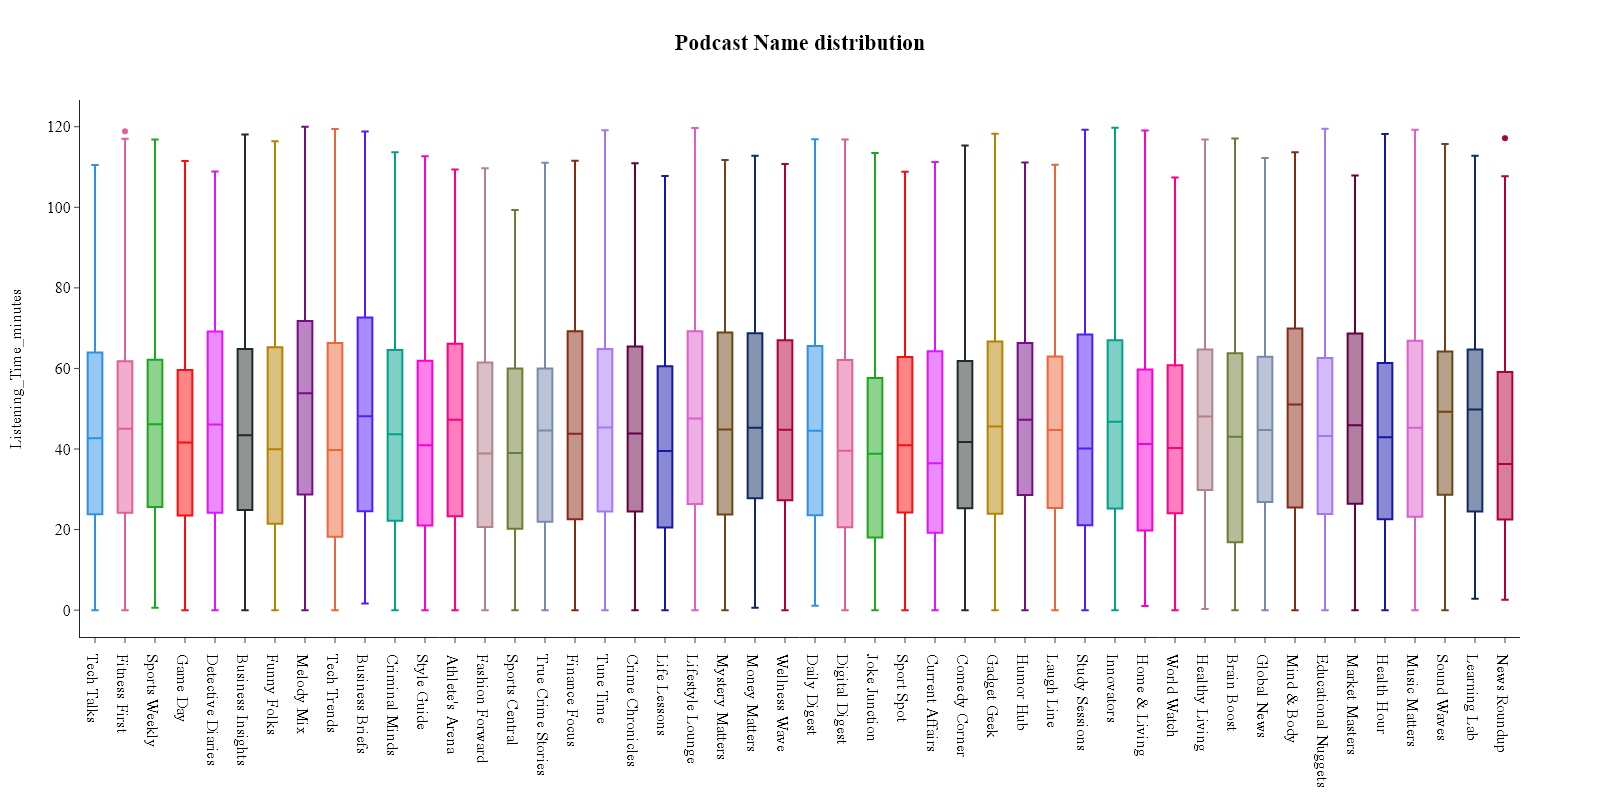

In [10]:
plots.boxplot_by_categorical(train_data, "Podcast_Name", "Listening_Time_minutes", "Podcast Name")

**Notes:**
- The listening time has almost the same distribution for all podcasts.

**Conclusion:**
- I will convert the column to `category` dtype as it is a categorical variable (converting to `category` dtype reduces memory usage).

In [11]:
train_data['Podcast_Name'] = train_data['Podcast_Name'].astype('category')
test_data['Podcast_Name'] = test_data['Podcast_Name'].astype('category')

## `Episode_Title`

`Episode_Title` is the title of the episode.

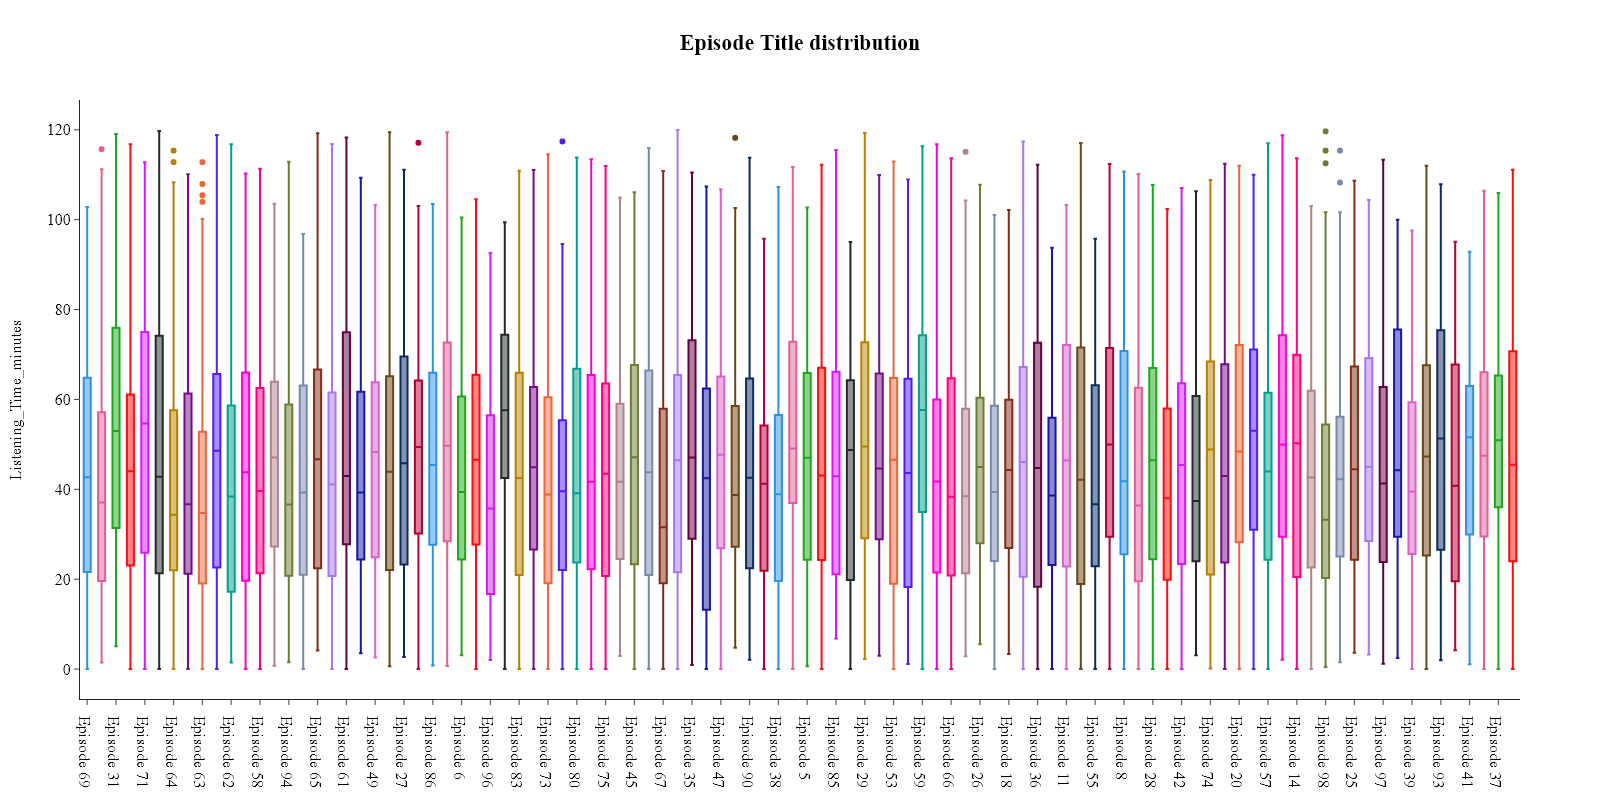

In [12]:
plots.boxplot_by_categorical(train_data, "Episode_Title", "Listening_Time_minutes", "Episode Title")

**Notes:**
- There are 100 distinct episode titles.

**Conclusion:**
- We will extract number of episode from the title and create a new feature called `Episode_Number` and encode it as categorical variable.
- We will drop `Episode_Title` after that.

In [13]:
train_data["Episode_Number"] = train_data["Episode_Title"].str.extract(r'(\d+)').astype("int32")
test_data["Episode_Number"] = test_data["Episode_Title"].str.extract(r'(\d+)').astype("int32")
train_data.drop("Episode_Title", axis=1, inplace=True)
test_data.drop("Episode_Title", axis=1, inplace=True)

## `Episode_Length_minutes`

`Episode_Length_minutes` is the length of the episode in minutes.

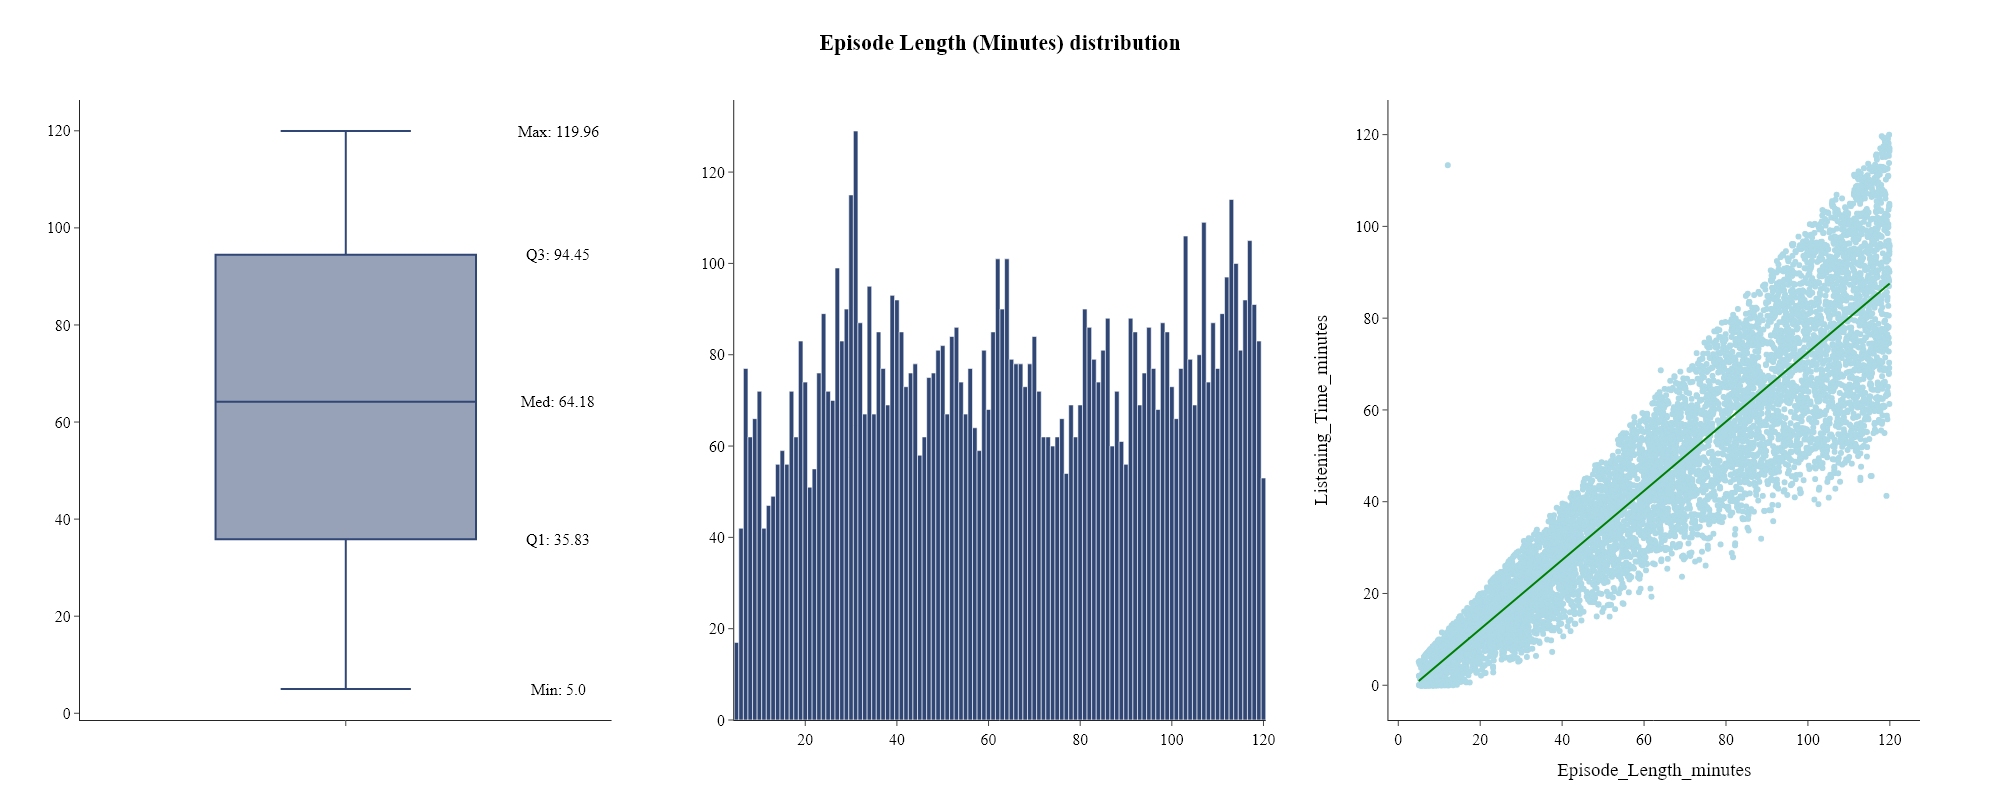

In [14]:
plots.histogram_boxplot_linear_regression(data=train_data, feature="Episode_Length_minutes", target="Listening_Time_minutes", name="Episode Length (minutes)", annotations=True, bin_size=1)

In [15]:
print(f"Number of observations with Episode Lenght Minute > 120: {len(train_data[train_data['Episode_Length_minutes'] > 120])} ({len(train_data[train_data['Episode_Length_minutes'] > 120])/len(train_data) * 100:.4f}%)")

Number of observations with Episode Lenght Minute > 120: 0 (0.0000%)


**Notes:**
- We can see that most of the data is between 0 and 120 minutes.

**Conclusion:**
- We will perform winsorization to keep the data between 0 and 120 minutes.

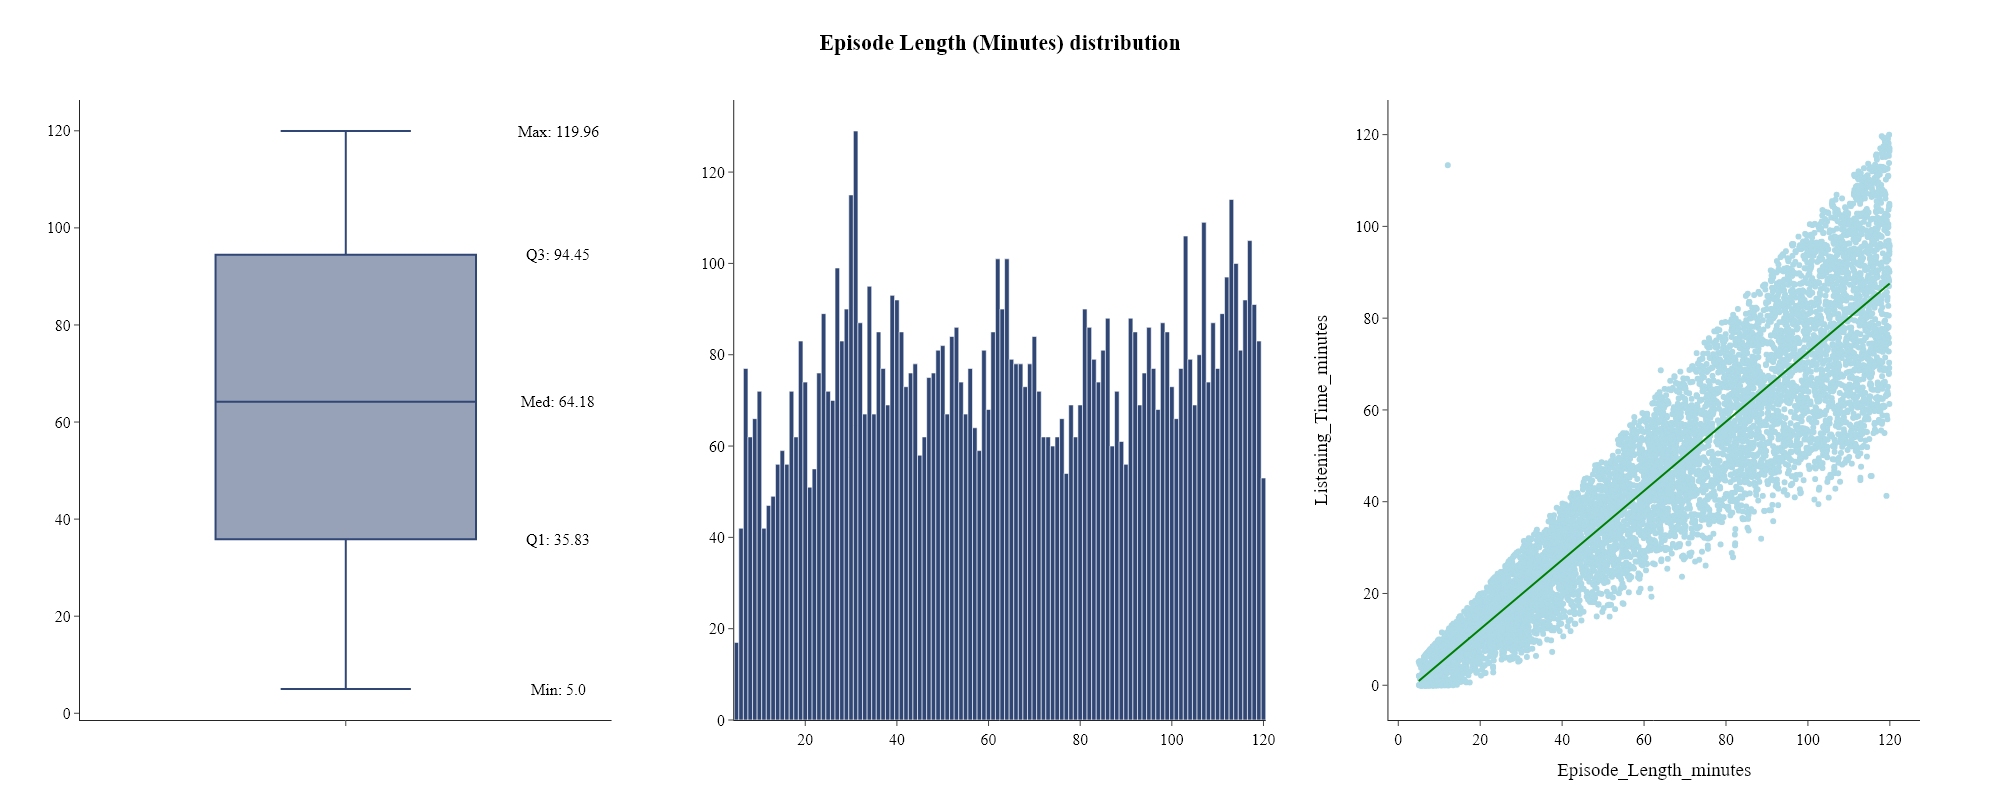

In [16]:
train_data["Episode_Length_minutes"] = np.clip(train_data["Episode_Length_minutes"], 0, 120)
test_data["Episode_Length_minutes"] = np.clip(test_data["Episode_Length_minutes"], 0, 120)
plots.histogram_boxplot_linear_regression(data=train_data, feature="Episode_Length_minutes", target="Listening_Time_minutes", name="Episode Length (minutes)", annotations=True, bin_size=1)

There are still plenty of outliers in this variable. 

To impute them we will use Median Imputation, however we will also create a new feature called `Episode_Length_minutes_Imputed` which will represent whether the value was imputed or not. 

This will be useful for our model to understand if the value was imputed or not.

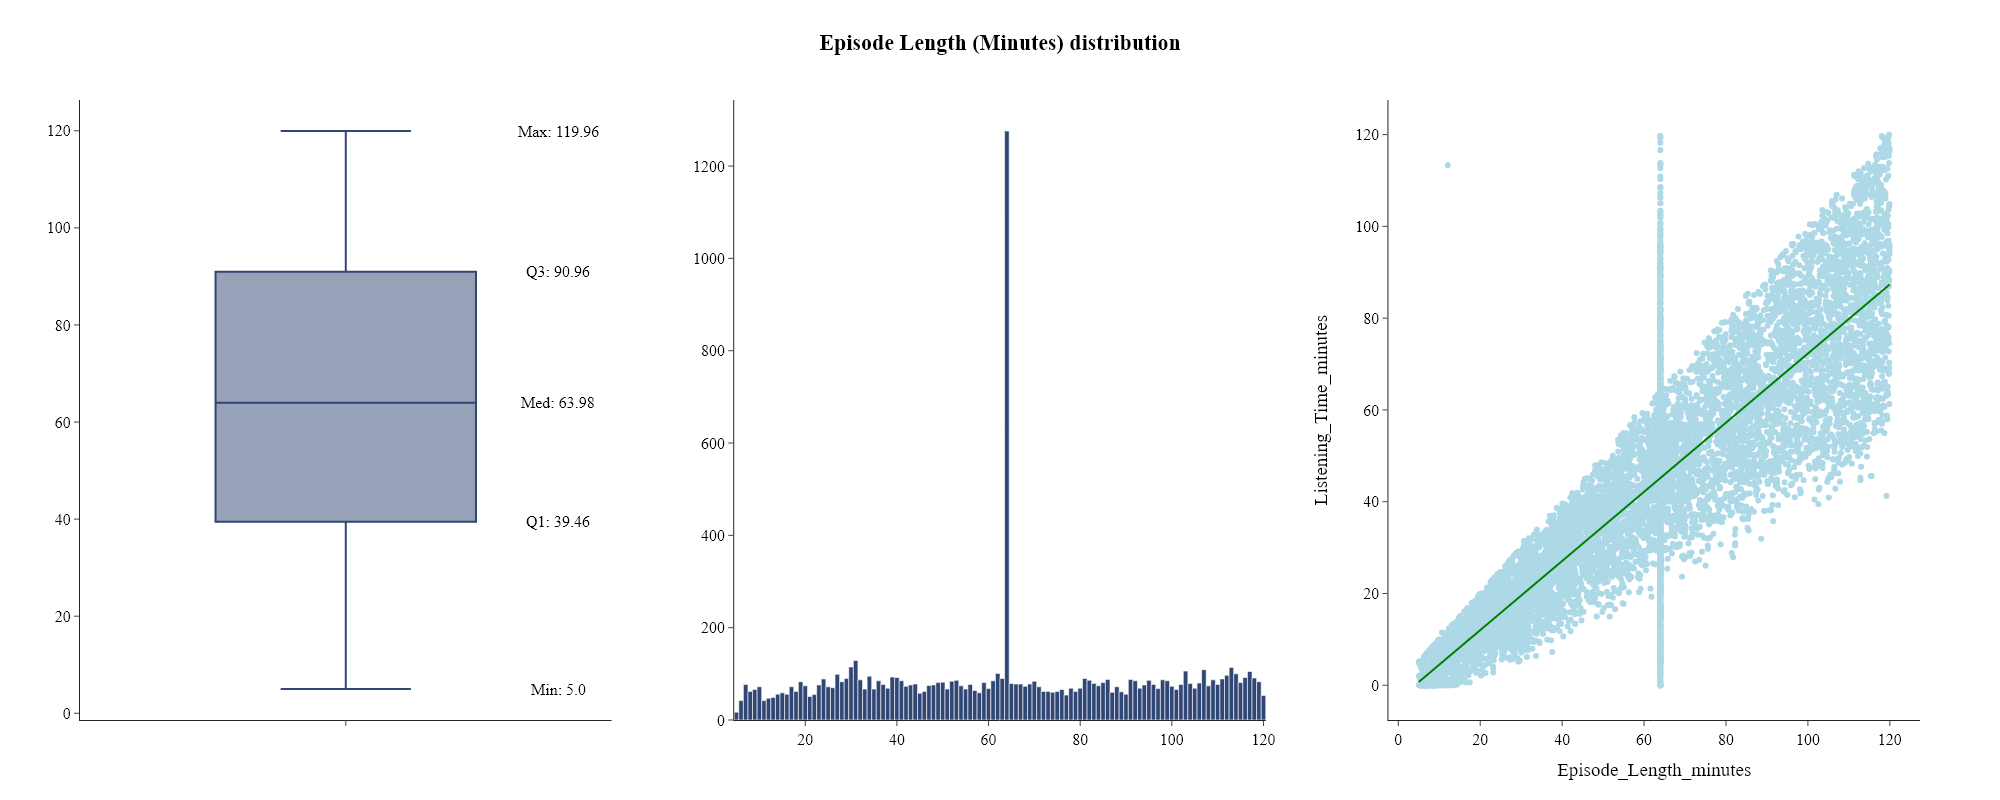

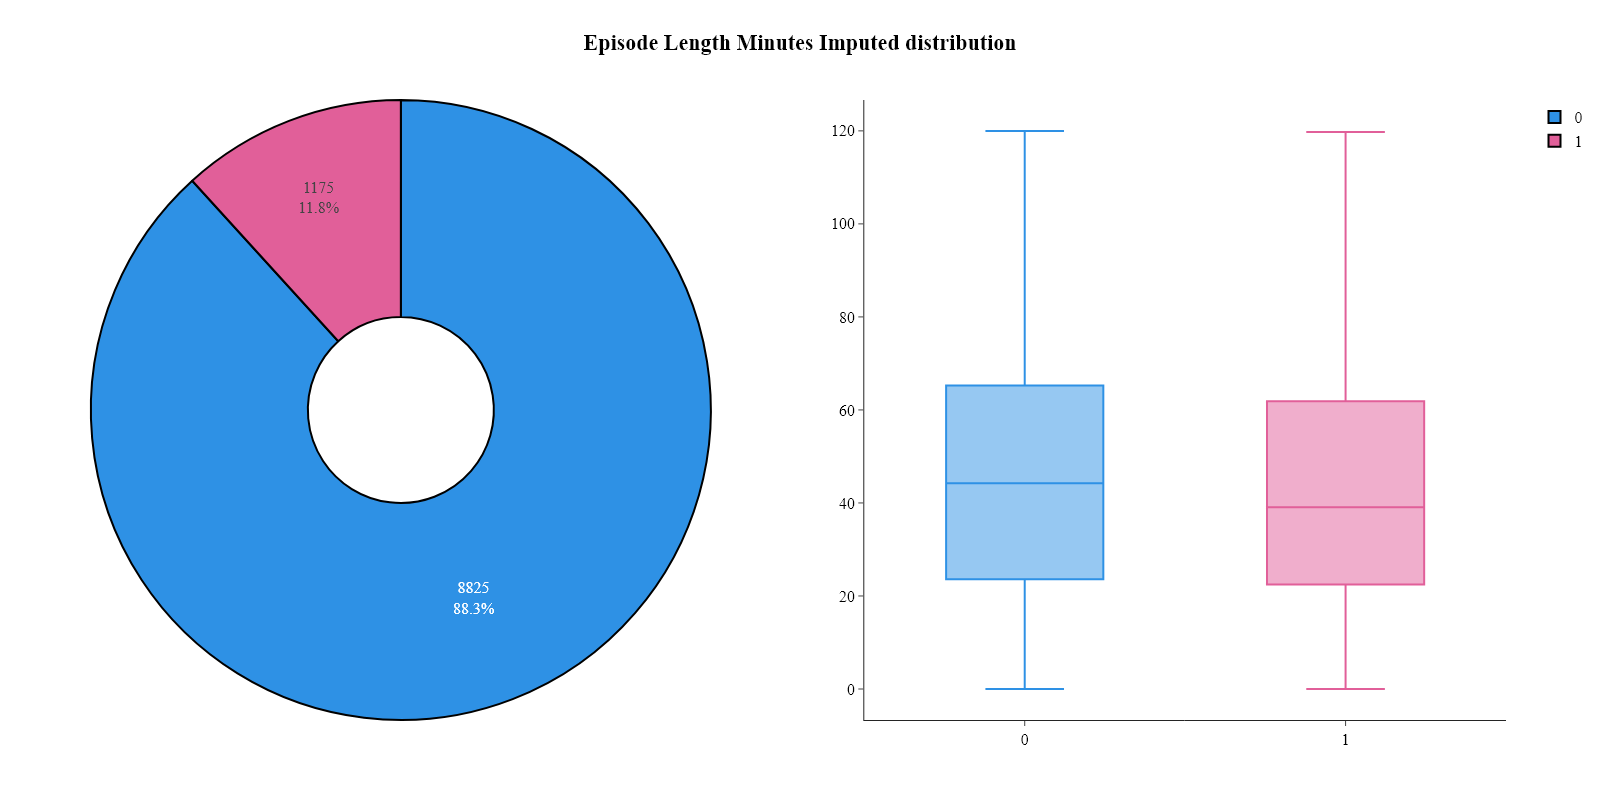

In [17]:
train_data.loc[:, "Episode_Length_minutes_Imputed"] = np.where(train_data["Episode_Length_minutes"].isna(), 1, 0)
test_data.loc[:, "Episode_Length_minutes_Imputed"] = np.where(test_data["Episode_Length_minutes"].isna(), 1, 0)
fillna_value = np.median(np.hstack([train_data["Episode_Length_minutes"].dropna(), test_data["Episode_Length_minutes"].dropna()]))
train_data.fillna({"Episode_Length_minutes": fillna_value}, inplace=True)
test_data.fillna({"Episode_Length_minutes": fillna_value}, inplace=True)
plots.histogram_boxplot_linear_regression(data=train_data, feature="Episode_Length_minutes", target="Listening_Time_minutes", name="Episode Length (minutes)", annotations=True, bin_size=1)
plots.pie_boxplot_by_categorical(train_data, "Episode_Length_minutes_Imputed", "Listening_Time_minutes", "Episode Length Minutes Imputed")

**Conclusion:**
- I will convert `Episode_Length_minutes` to `float` dtype as it is a continuous variable.
- I will convert `Episode_Length_minutes_Imputed` to `category` dtype as it is a categorical variable (converting to `category` dtype reduces memory usage).

In [18]:
train_data["Episode_Length_minutes"] = train_data["Episode_Length_minutes"].astype("float32")
test_data["Episode_Length_minutes"] = test_data["Episode_Length_minutes"].astype("float32")
train_data["Episode_Length_minutes_Imputed"] = train_data["Episode_Length_minutes_Imputed"].astype("category")
test_data["Episode_Length_minutes_Imputed"] = test_data["Episode_Length_minutes_Imputed"].astype("category")

## `Genre`

`Genre` is the genre of the podcast. It is a categorical variable with 10 distinct values.

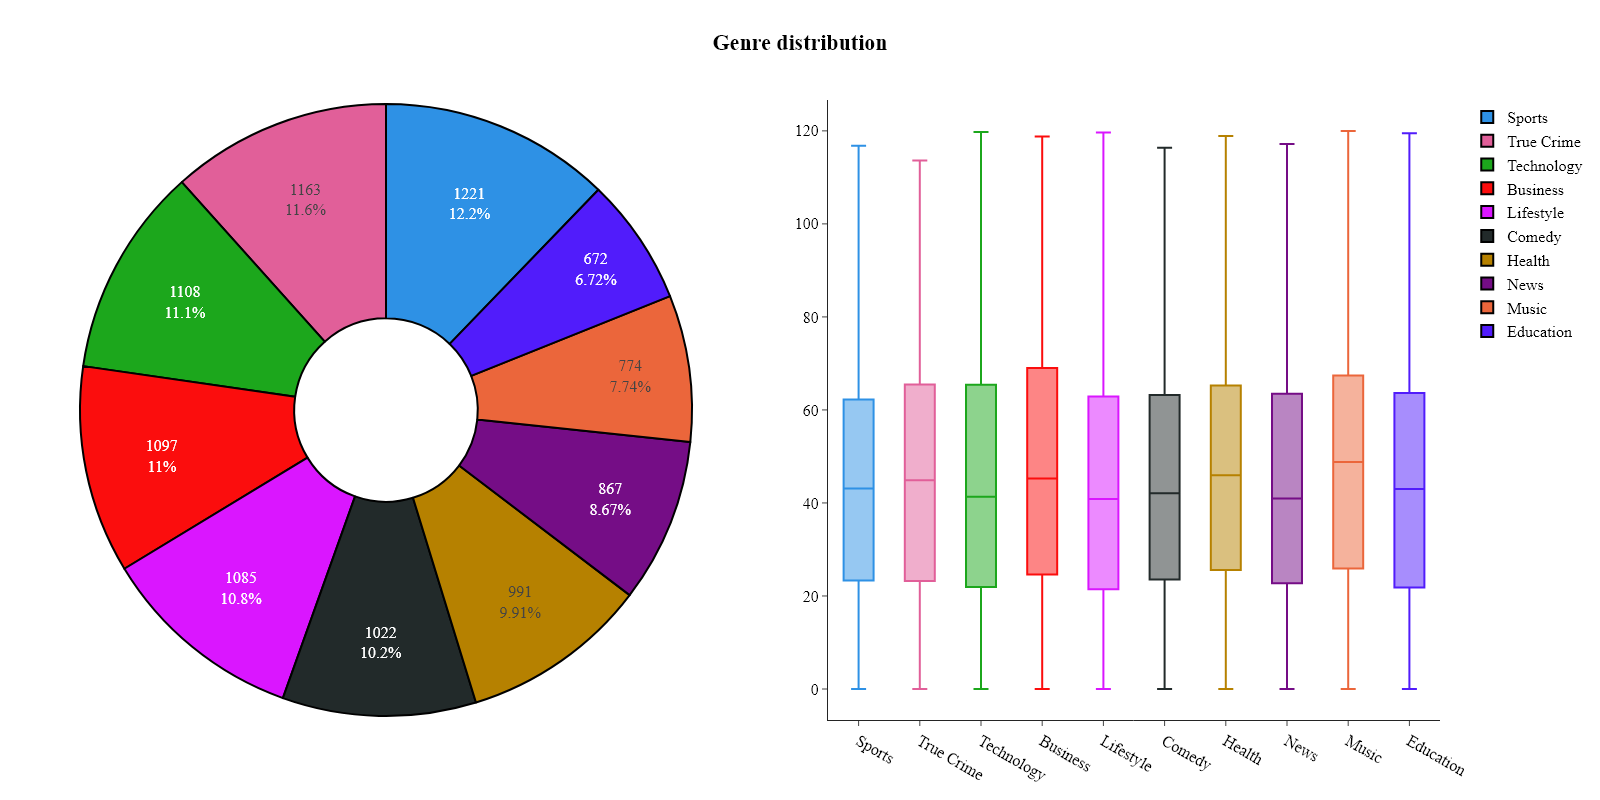

In [19]:
plots.pie_boxplot_by_categorical(train_data, "Genre", "Listening_Time_minutes", "Genre")

**Notes:**
- We can see that distribution of listening time is pretty similar for all genres.

**Conclusion:**
- I will convert the column to `category` dtype as it is a categorical variable (converting to `category` dtype reduces memory usage).

In [20]:
train_data["Genre"] = train_data["Genre"].astype("category")
test_data["Genre"] = test_data["Genre"].astype("category")

## `Host_Popularity_percentage`

`Host_Popularity_percentage` is the popularity of the host in percentage, where host is the person who created the podcast.

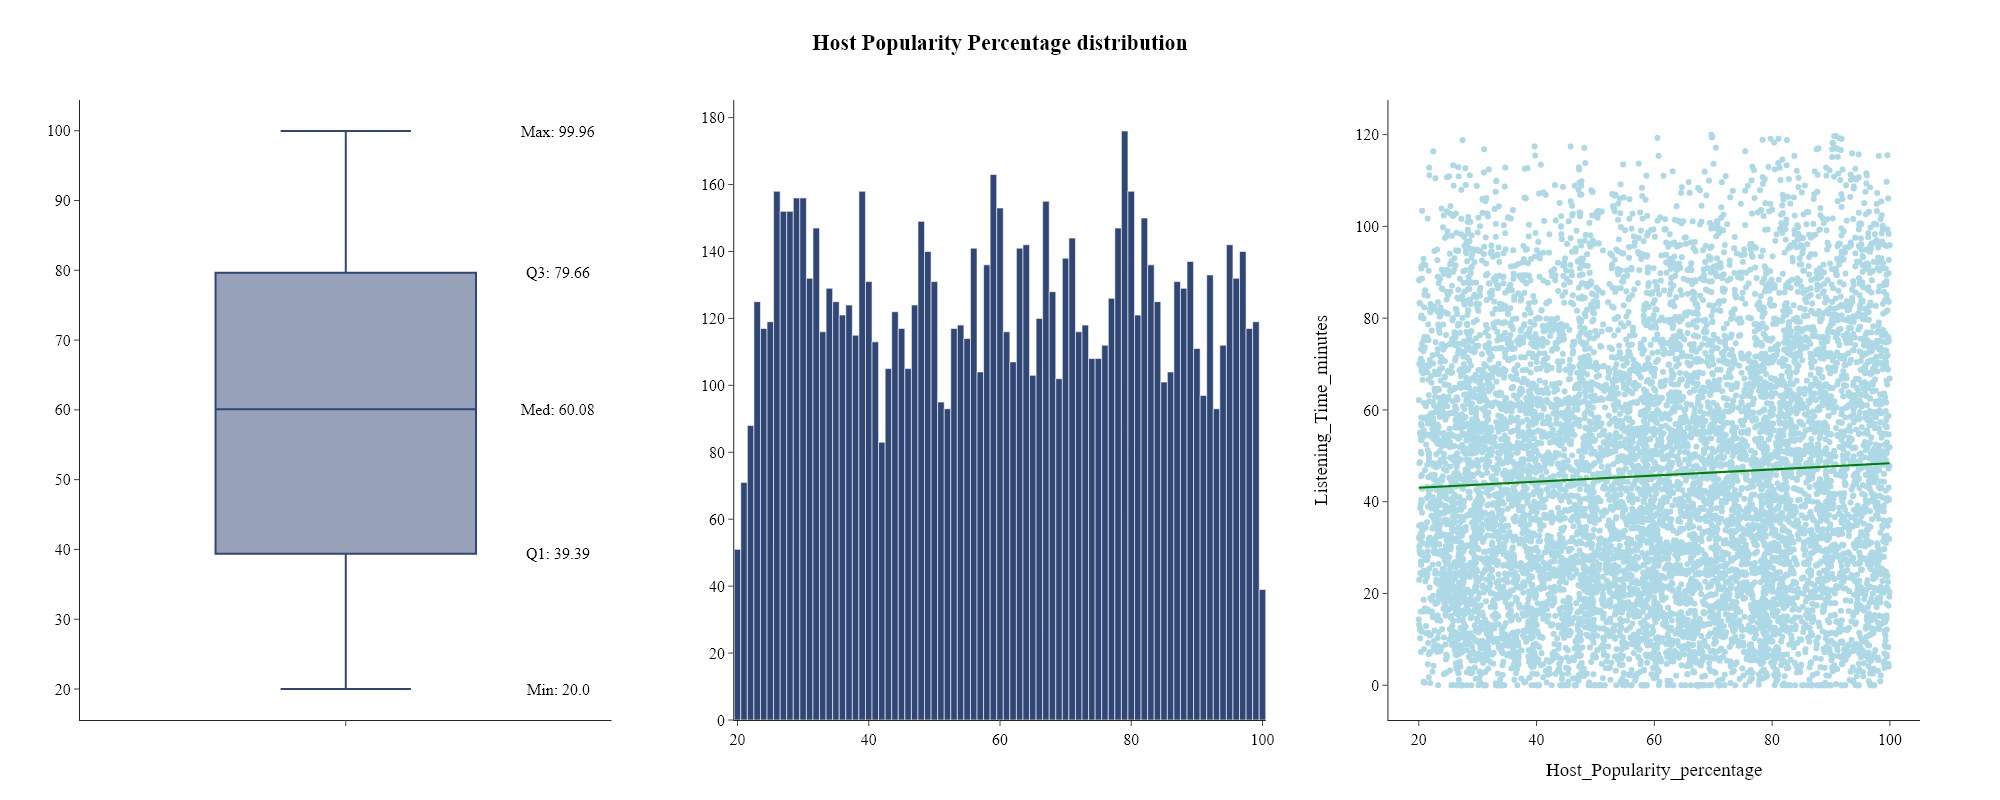

In [21]:
plots.histogram_boxplot_linear_regression(data=train_data, feature="Host_Popularity_percentage", target="Listening_Time_minutes", name="Host Popularity Percentage", annotations=True, bin_size=1)

In [22]:
print(f"Number of observations with Host Popularity Percentage < 20 or > 100: {len(train_data[(train_data['Host_Popularity_percentage'] < 20) | (train_data['Host_Popularity_percentage'] > 100)])} ({len(train_data[(train_data['Host_Popularity_percentage'] < 20) | (train_data['Host_Popularity_percentage'] > 100)]) / len(train_data) * 100:.4f}%)")

Number of observations with Host Popularity Percentage < 20 or > 100: 0 (0.0000%)


**Notes:**
- We can see that most of the data is between 20 and 100 percent.

**Conclusion:**
- We will perform winsorization to keep the data between 20 and 100 percent.

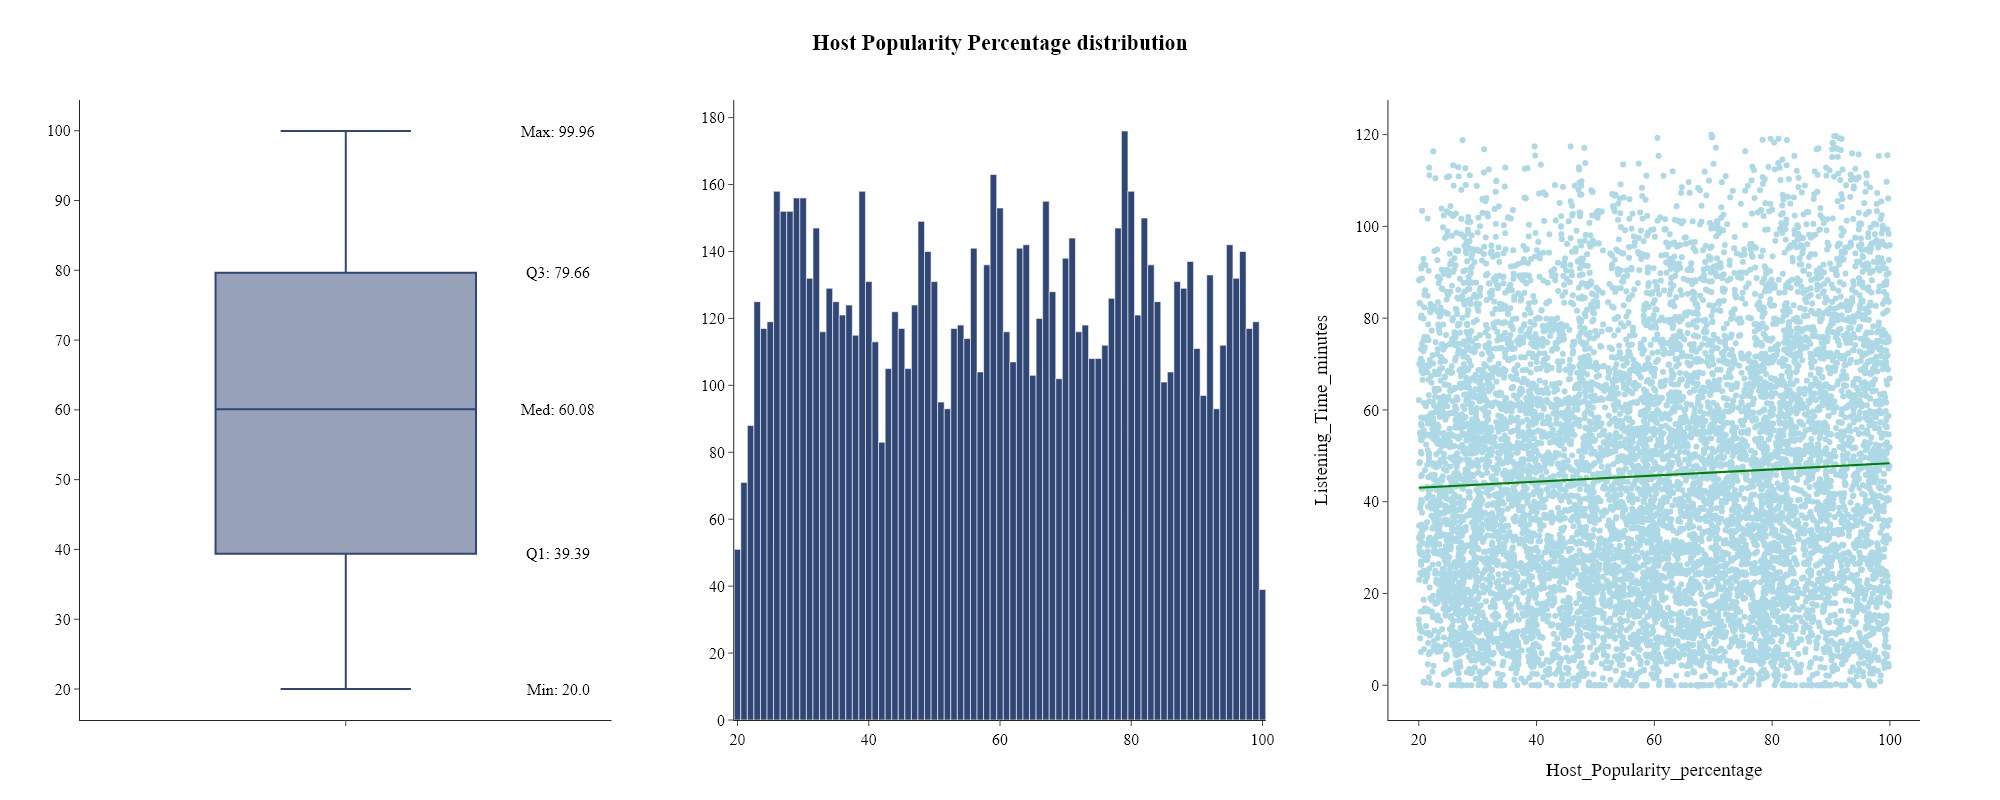

In [23]:
train_data["Host_Popularity_percentage"] = np.clip(train_data["Host_Popularity_percentage"], 20, 100)
test_data["Host_Popularity_percentage"] = np.clip(test_data["Host_Popularity_percentage"], 20, 100)
plots.histogram_boxplot_linear_regression(data=train_data, feature="Host_Popularity_percentage", target="Listening_Time_minutes", name="Host Popularity Percentage", annotations=True, bin_size=1)

**Conclusion:**
- I will convert the column to `float` dtype as it is a numerical variable.

In [24]:
train_data["Host_Popularity_percentage"] = train_data["Host_Popularity_percentage"].astype("float32")
test_data["Host_Popularity_percentage"] = test_data["Host_Popularity_percentage"].astype("float32")

## `Publication_Day`

`Publication_Day` is the day of the week when the episode was published.

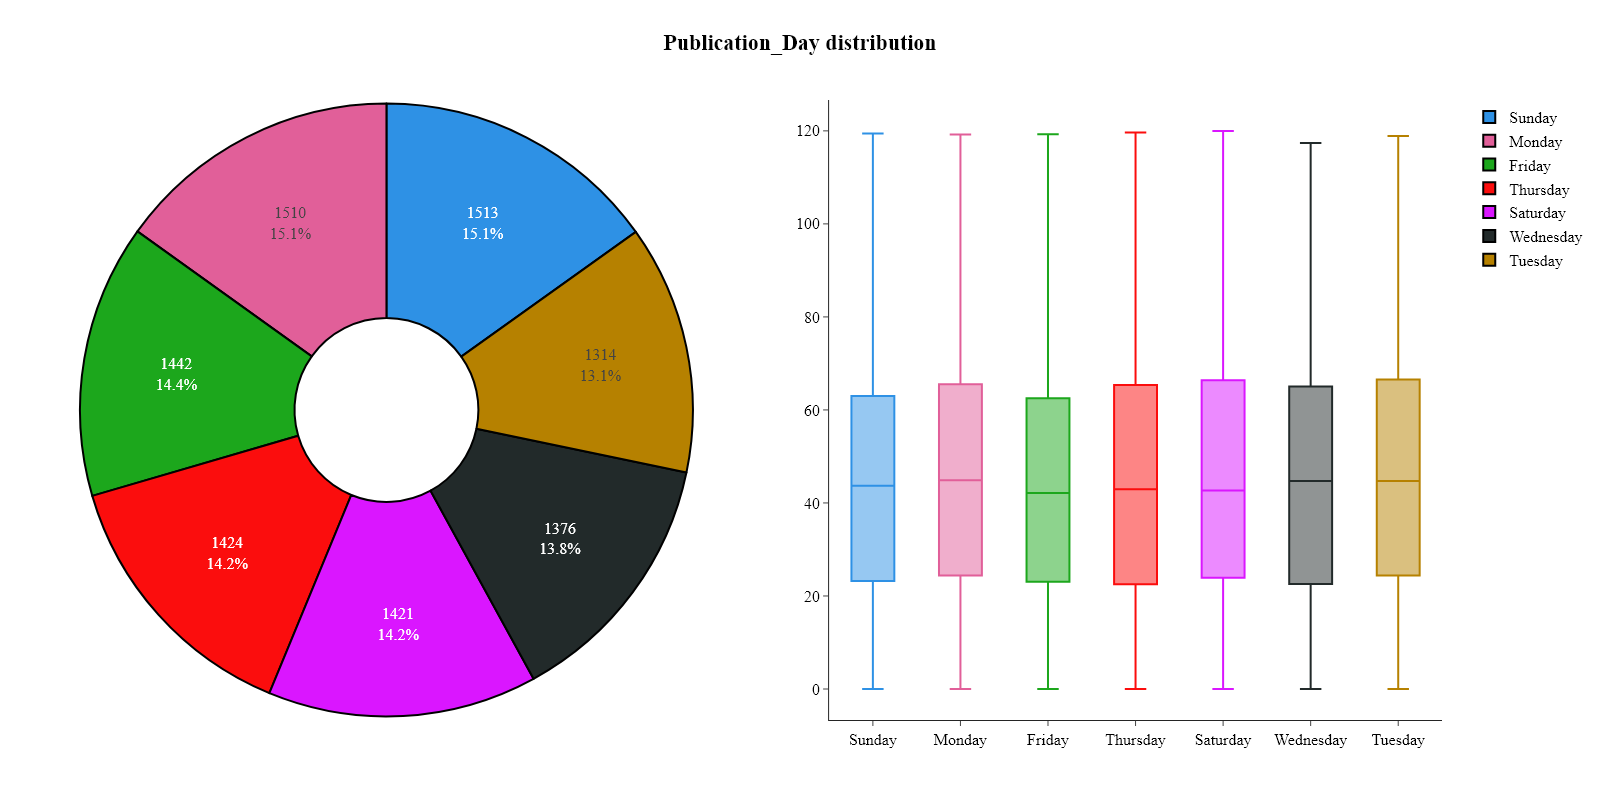

In [25]:
plots.pie_boxplot_by_categorical(train_data, "Publication_Day", "Listening_Time_minutes", "Publication_Day")

**Notes:**
- The distribution of publication day is pretty similar for all days of the week.

**Conclusion:**
- I will create a new feature called `is_weekend` which will represent whether the episode was published on a weekend or not.
- I will convert the column to `category` dtype as it is a categorical variable (converting to `category` dtype reduces memory usage).

In [26]:
train_data["is_weekend"] = train_data["Publication_Day"].isin(["Saturday", "Sunday"]).astype("category")
test_data["is_weekend"] = test_data["Publication_Day"].isin(["Saturday", "Sunday"]).astype("category")
train_data["Publication_Day"] = train_data["Publication_Day"].astype("category")
test_data["Publication_Day"] = test_data["Publication_Day"].astype("category")

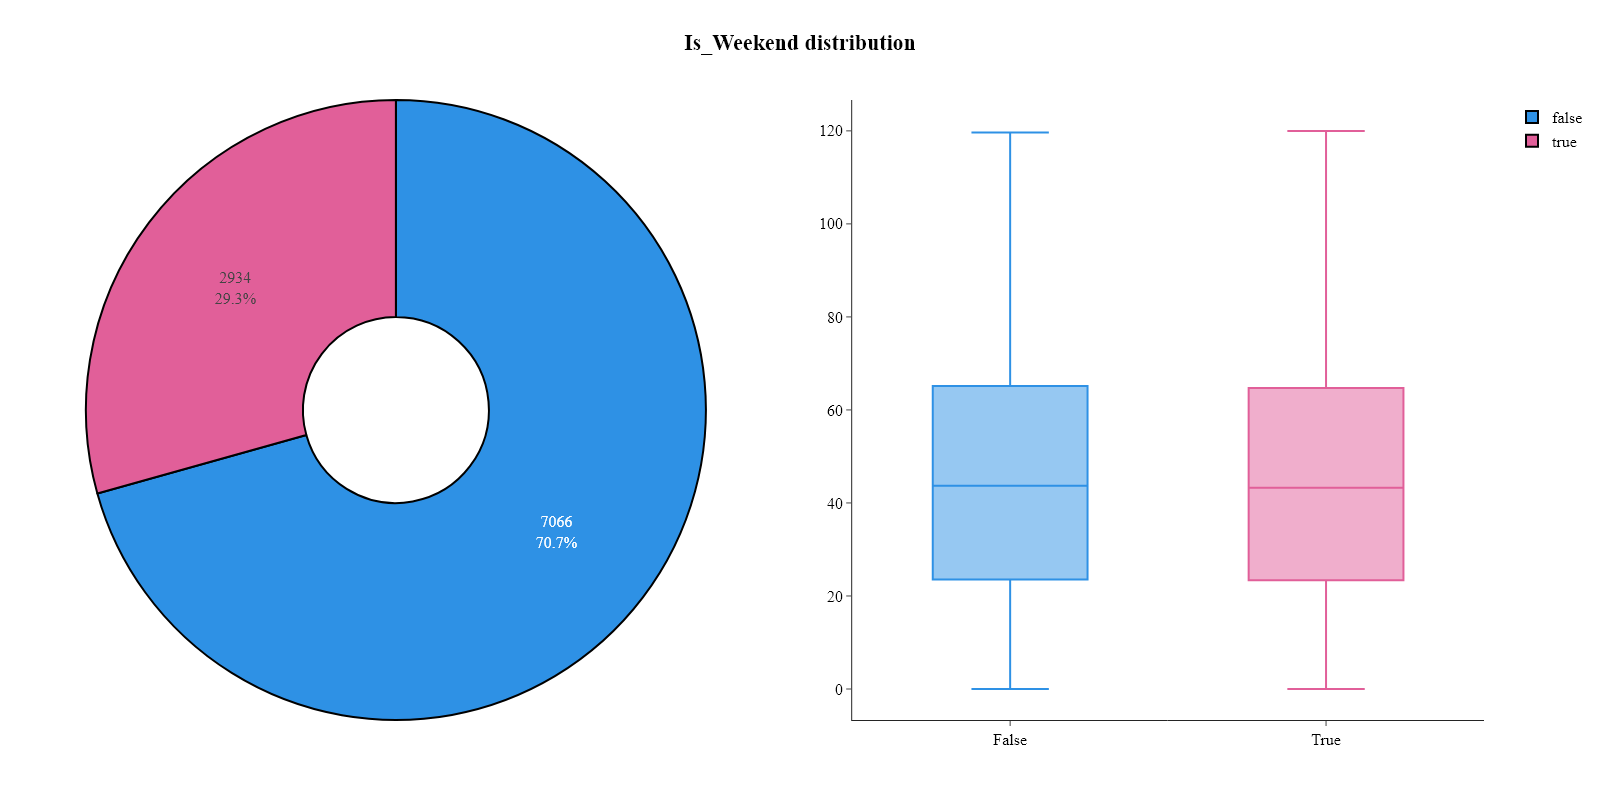

In [27]:
plots.pie_boxplot_by_categorical(train_data, "is_weekend", "Listening_Time_minutes", "is_weekend")

## `Publication_Time`

`Publication_Time` is the time of the day when the episode was published.

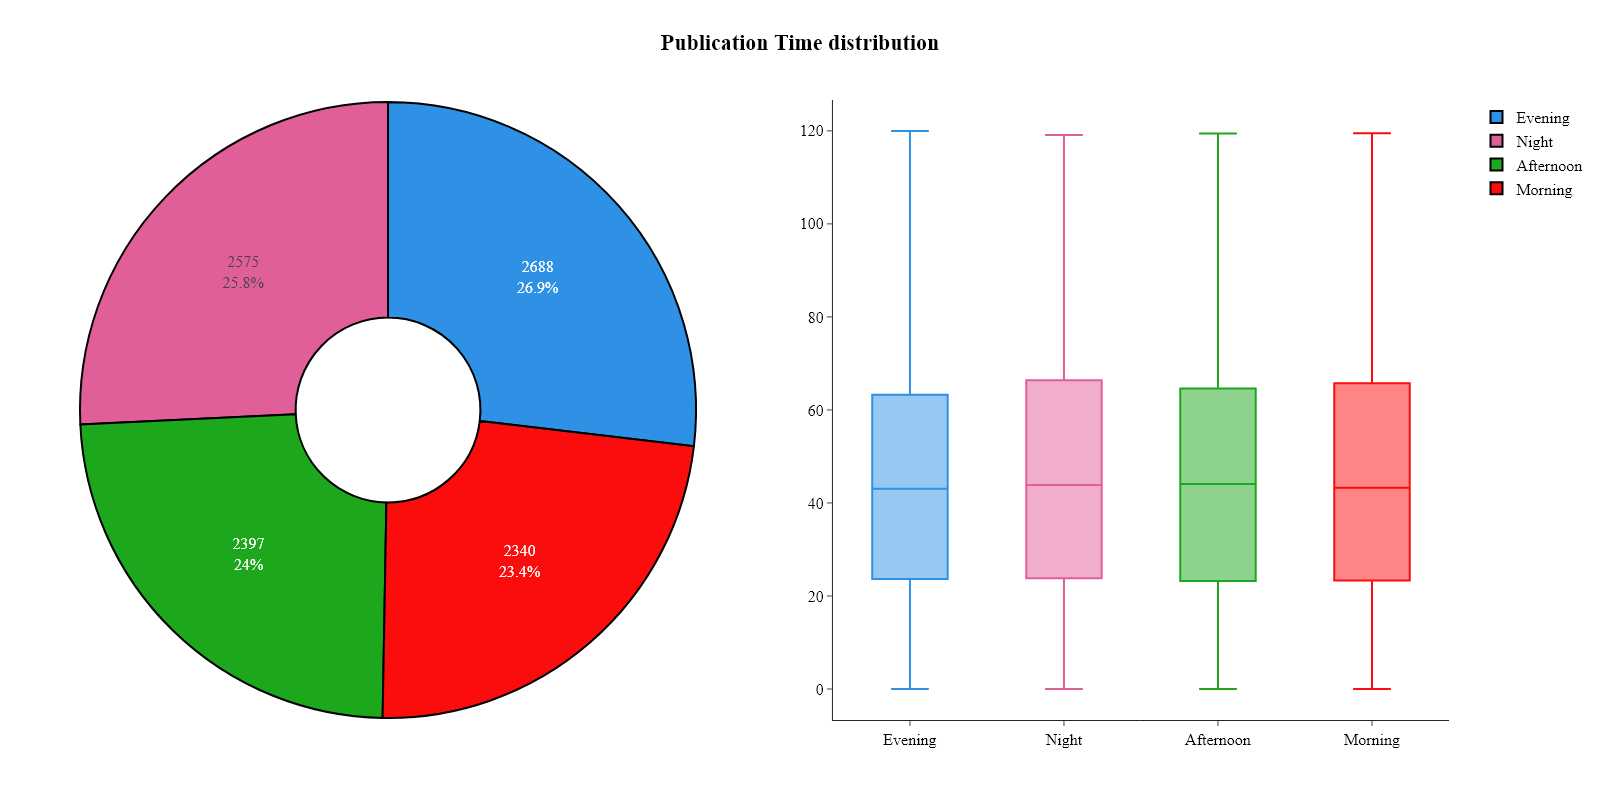

In [28]:
plots.pie_boxplot_by_categorical(train_data, "Publication_Time", "Listening_Time_minutes", "Publication Time")

**Notes:**
- Similarly to the publication day, the distribution of publication time is pretty similar for all times of the day.

**Conclusion:**
- I will convert the column to `category` dtype as it is a categorical variable (converting to `category` dtype reduces memory usage).

In [29]:
train_data["Publication_Time"] = train_data["Publication_Time"].astype("category")
test_data["Publication_Time"] = test_data["Publication_Time"].astype("category")

## `Guest_Popularity_percentage`

`Guest_Popularity_percentage` is the popularity of the guest in percentage, where guest is the person who was invited to the podcast.

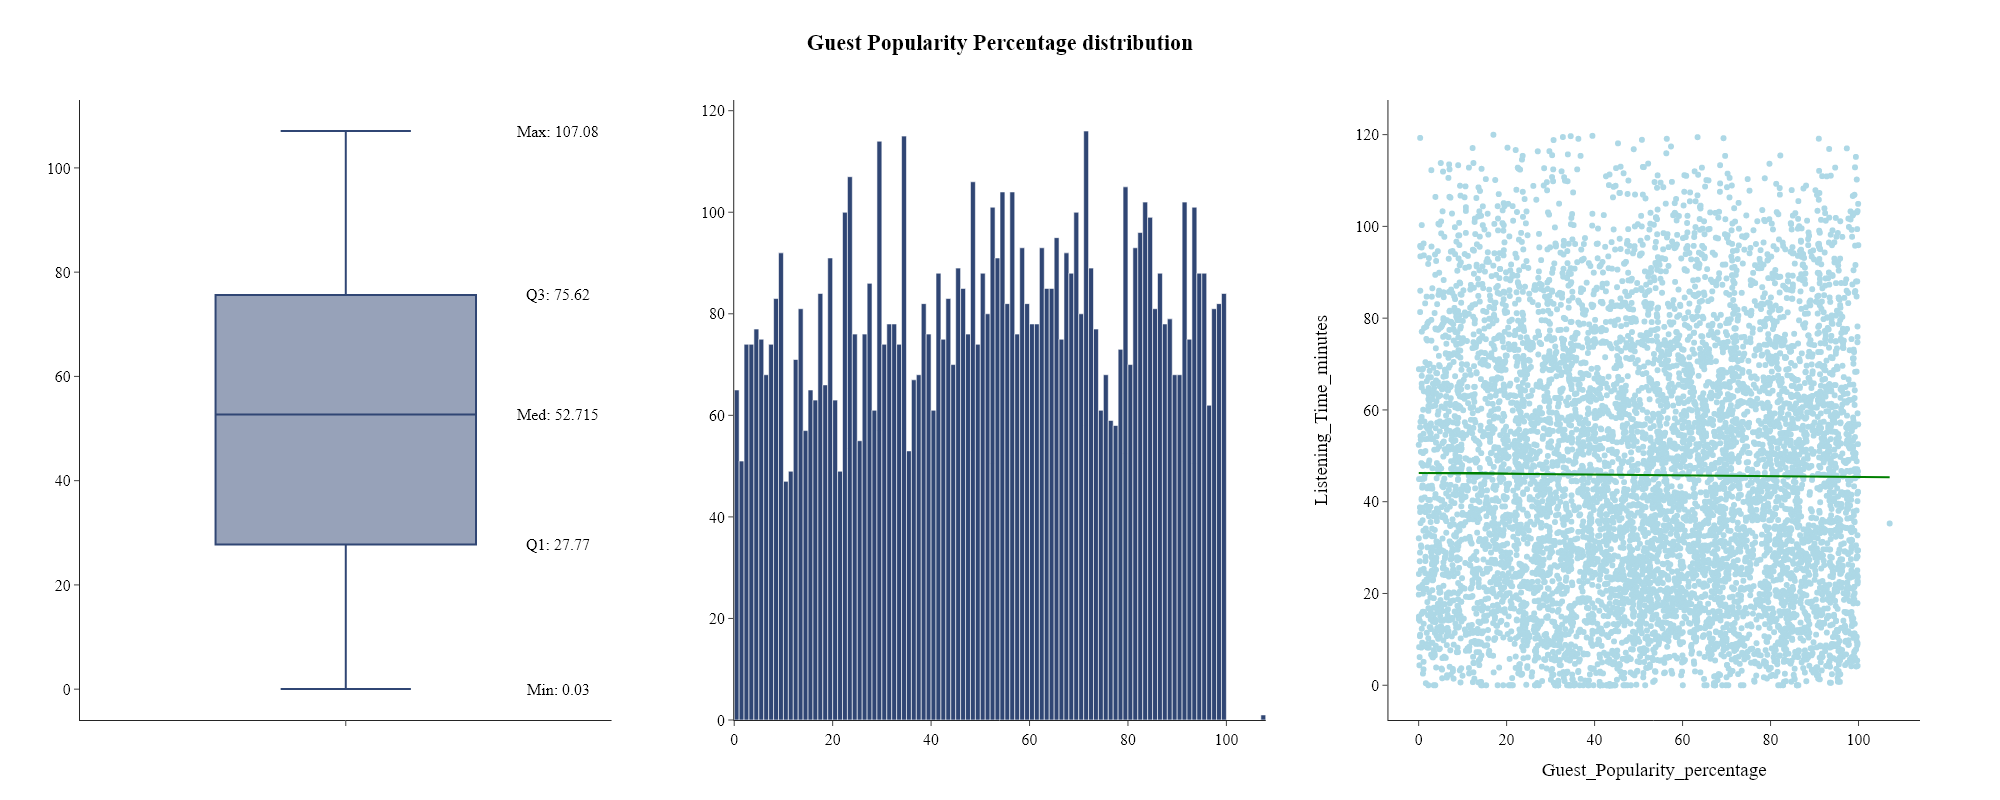

In [30]:
plots.histogram_boxplot_linear_regression(data=train_data, feature="Guest_Popularity_percentage", target="Listening_Time_minutes", name="Guest Popularity Percentage", annotations=True, bin_size=1)

In [31]:
print(f"Number of observations with Host Popularity Percentage > 100: {len(train_data[train_data['Host_Popularity_percentage'] > 100])} ({len(train_data[train_data['Host_Popularity_percentage'] > 100]) / len(train_data) * 100:.4f}%)")

Number of observations with Host Popularity Percentage > 100: 0 (0.0000%)


**Notes:**
- We will perform winsorization to keep the data belowe 100 percent.

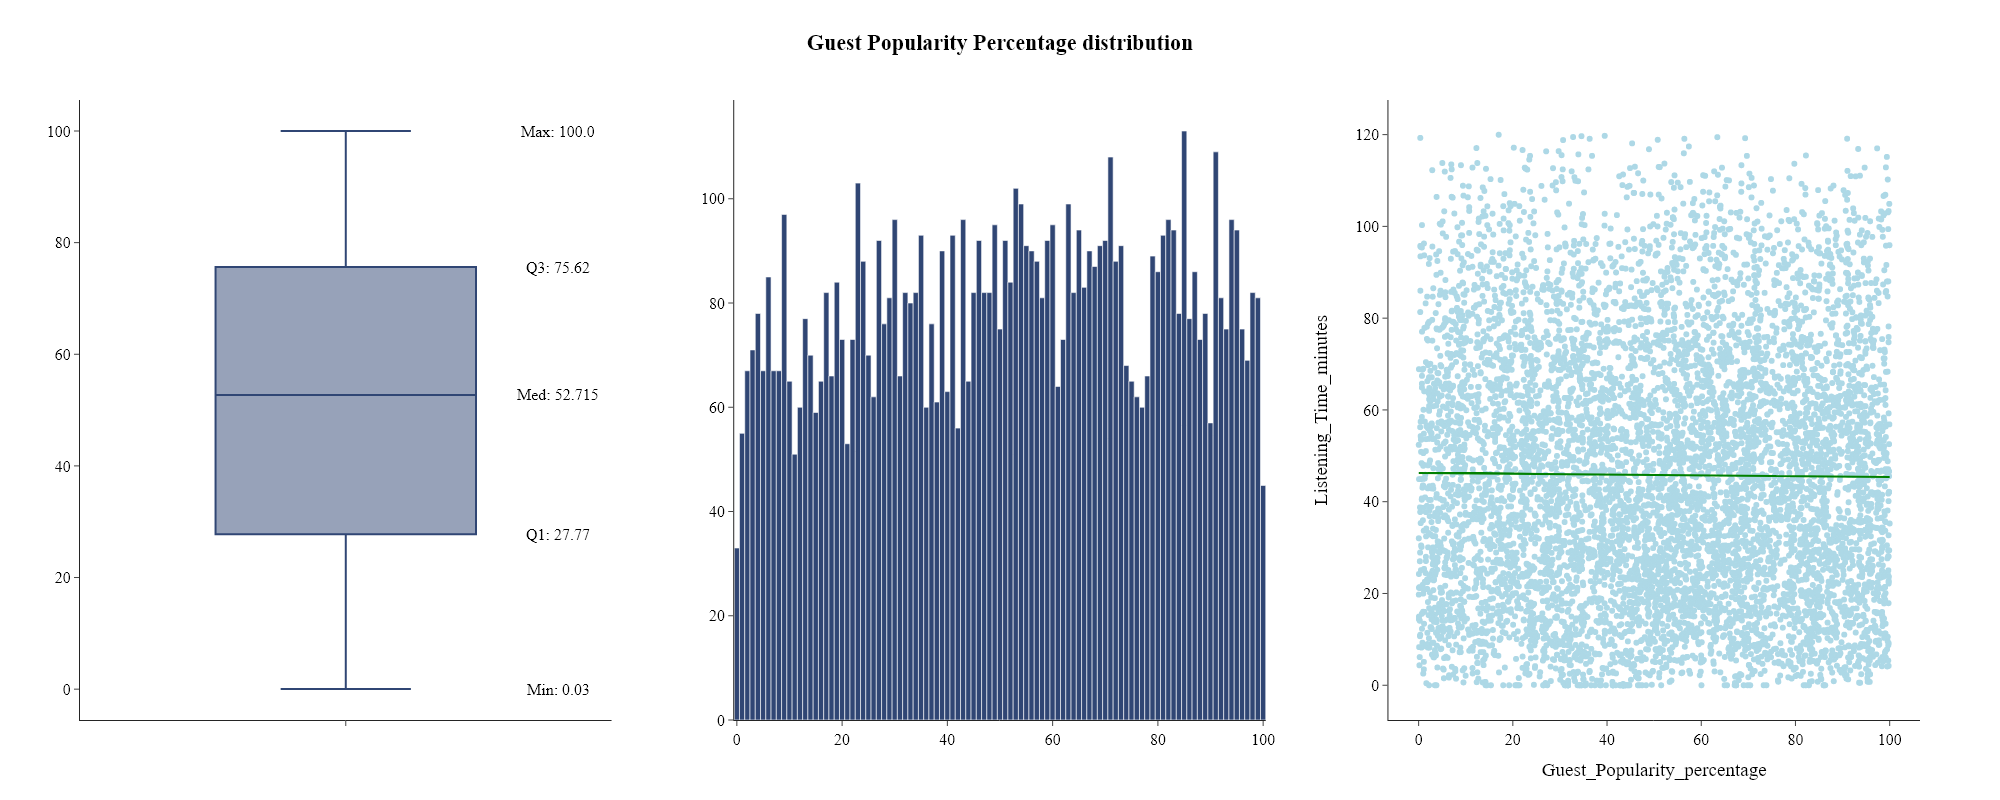

In [32]:
train_data["Guest_Popularity_percentage"] = np.clip(train_data["Guest_Popularity_percentage"], 0, 100)
test_data["Guest_Popularity_percentage"] = np.clip(test_data["Guest_Popularity_percentage"], 0, 100)
plots.histogram_boxplot_linear_regression(data=train_data, feature="Guest_Popularity_percentage", target="Listening_Time_minutes", name="Guest Popularity Percentage", annotations=True, bin_size=1)

Similarly to length of the episode we will perform an imputation for this variable by using Median Imputation and creating a new feature called `Guest_Popularity_percentage_Imputed` which will represent whether the value was imputed or not.

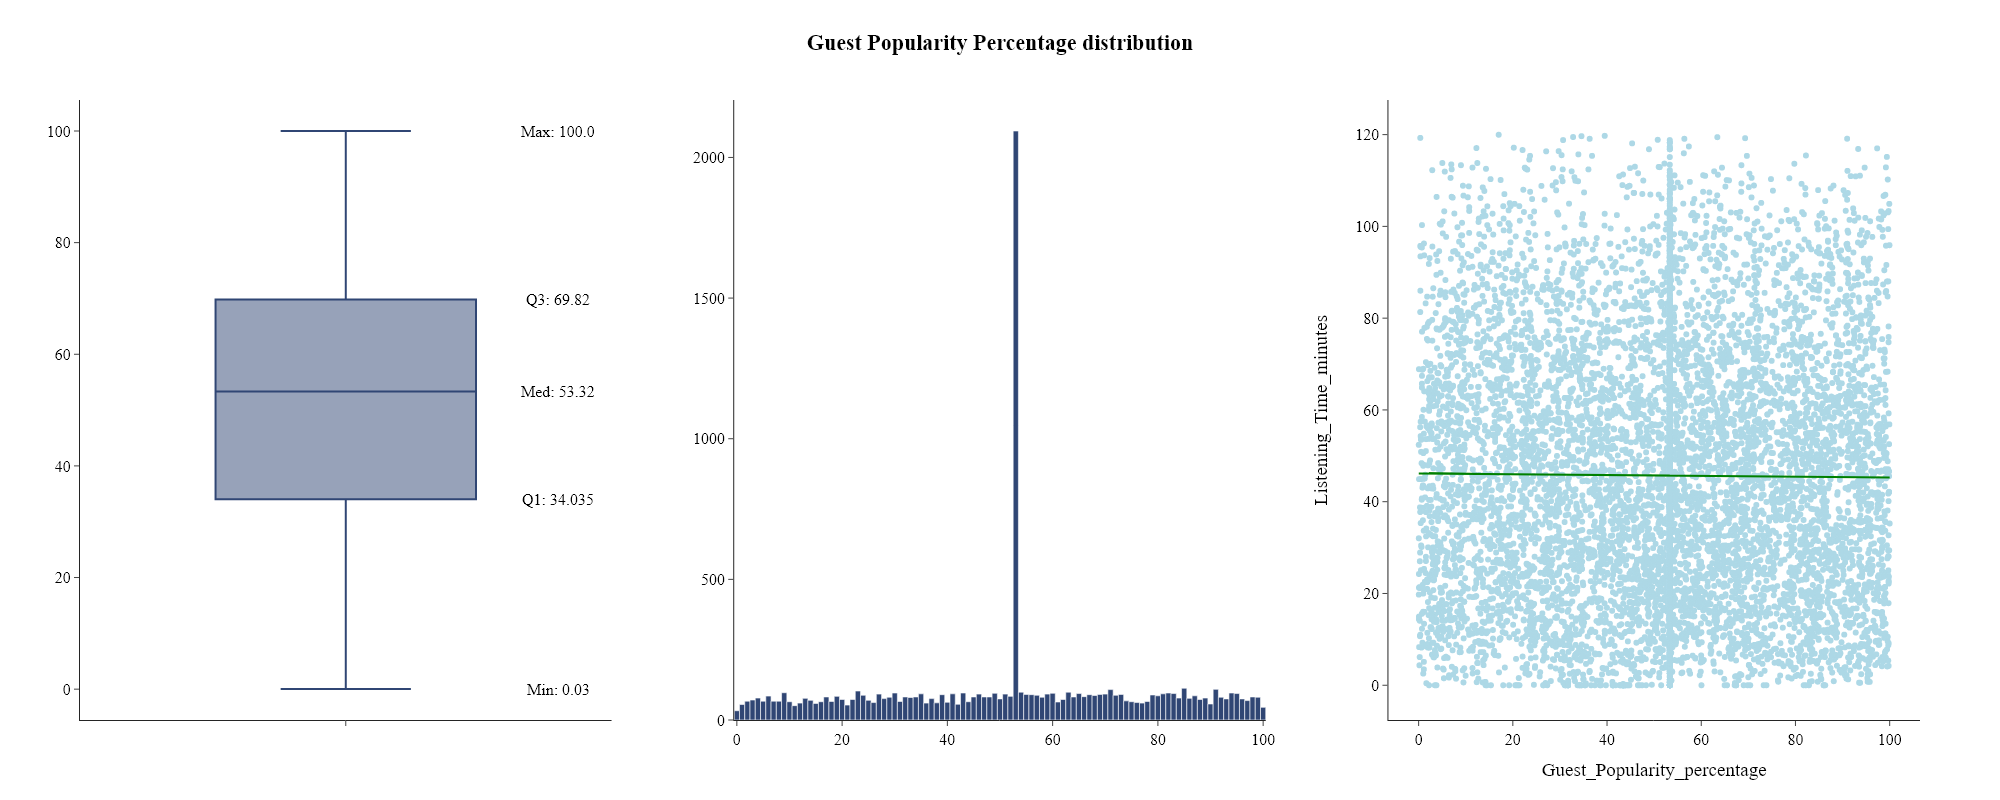

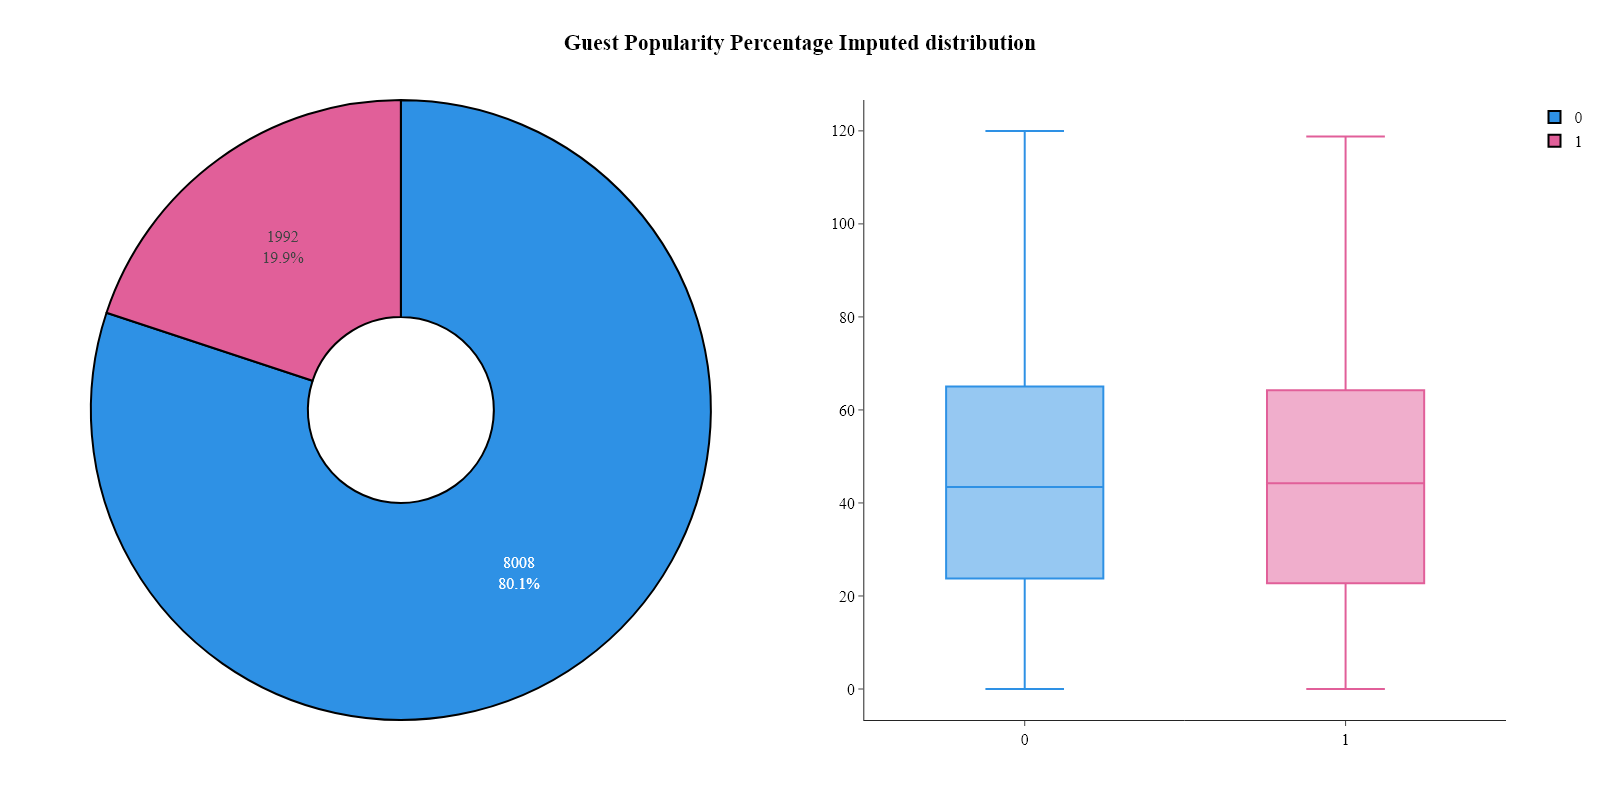

In [33]:
train_data.loc[:, "Guest_Popularity_percentage_Imputed"] = np.where(train_data["Guest_Popularity_percentage"].isna(), 1, 0)
test_data.loc[:, "Guest_Popularity_percentage_Imputed"] = np.where(test_data["Guest_Popularity_percentage"].isna(), 1, 0)
fillna_value = np.median(np.hstack([train_data["Guest_Popularity_percentage"].dropna(), test_data["Guest_Popularity_percentage"].dropna()]))
train_data.fillna({"Guest_Popularity_percentage": fillna_value}, inplace=True)
test_data.fillna({"Guest_Popularity_percentage": fillna_value}, inplace=True)
plots.histogram_boxplot_linear_regression(data=train_data, feature="Guest_Popularity_percentage", target="Listening_Time_minutes", name="Guest Popularity Percentage", annotations=True, bin_size=1)
plots.pie_boxplot_by_categorical(train_data, "Guest_Popularity_percentage_Imputed", "Listening_Time_minutes", "Guest Popularity Percentage Imputed")

**Conclusion:**
- I will create a new feature called `popularity_ratio` which will represent the ratio between guest and host popularity.
- I will convert `Guest_Popularity_percentage` to `float` dtype as it is a numerical variable.
- I will convert `Guest_Popularity_percentage_Imputed` to `category` dtype as it is a categorical variable (converting to `category` dtype reduces memory usage).

In [34]:
train_data["popularity_ratio"] = np.where(train_data["Host_Popularity_percentage"] == 0, 0, train_data["Guest_Popularity_percentage"] / train_data["Host_Popularity_percentage"])
test_data["popularity_ratio"] = np.where(test_data["Host_Popularity_percentage"] == 0, 0, test_data["Guest_Popularity_percentage"] / test_data["Host_Popularity_percentage"])
train_data["Guest_Popularity_percentage"] = train_data["Guest_Popularity_percentage"].astype("float32")
test_data["Guest_Popularity_percentage"] = test_data["Guest_Popularity_percentage"].astype("float32")
train_data["Guest_Popularity_percentage_Imputed"] = train_data["Guest_Popularity_percentage_Imputed"].astype("category")
test_data["Guest_Popularity_percentage_Imputed"] = test_data["Guest_Popularity_percentage_Imputed"].astype("category")

## `Number_of_Ads`

`Number_of_Ads` is the number of ads in the episode.

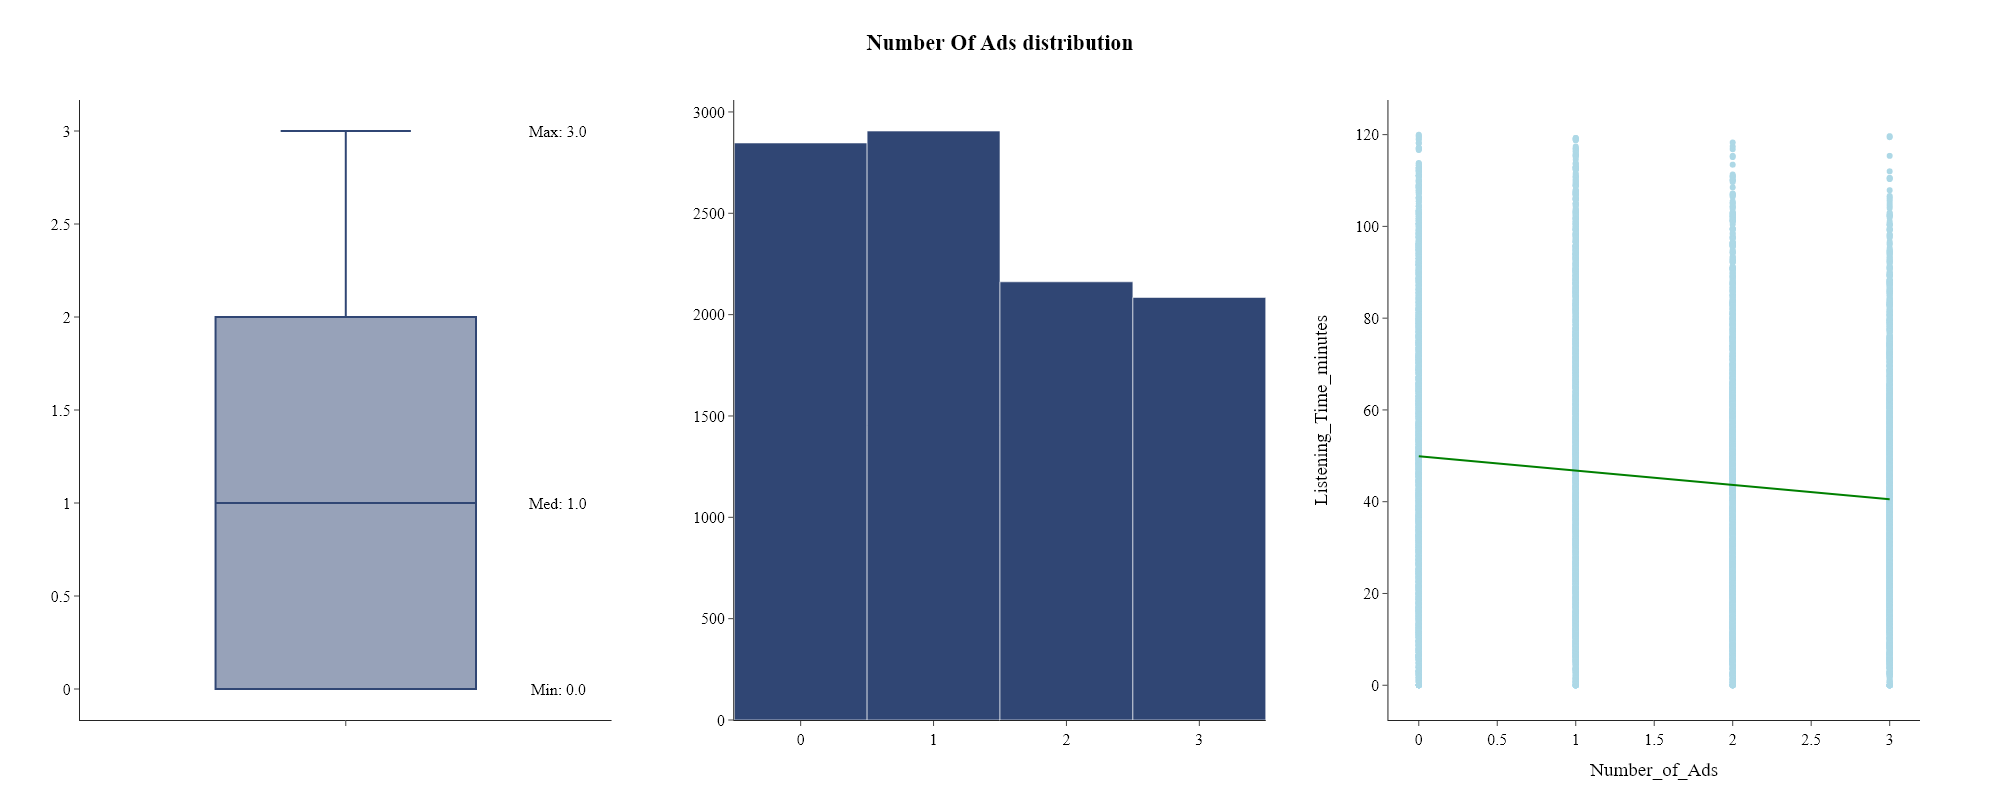

In [35]:
plots.histogram_boxplot_linear_regression(data=train_data, feature="Number_of_Ads", target="Listening_Time_minutes", name="Number of Ads", annotations=["Min", "Med", "Max"], bin_size=1)

**Notes:**
- Number of ads contain outliers.
- There is one missing value in this variable. We will impute it with the most frequent value.

**Conclusion:**
- To impute outliers we will convert the values above 3 to 4.

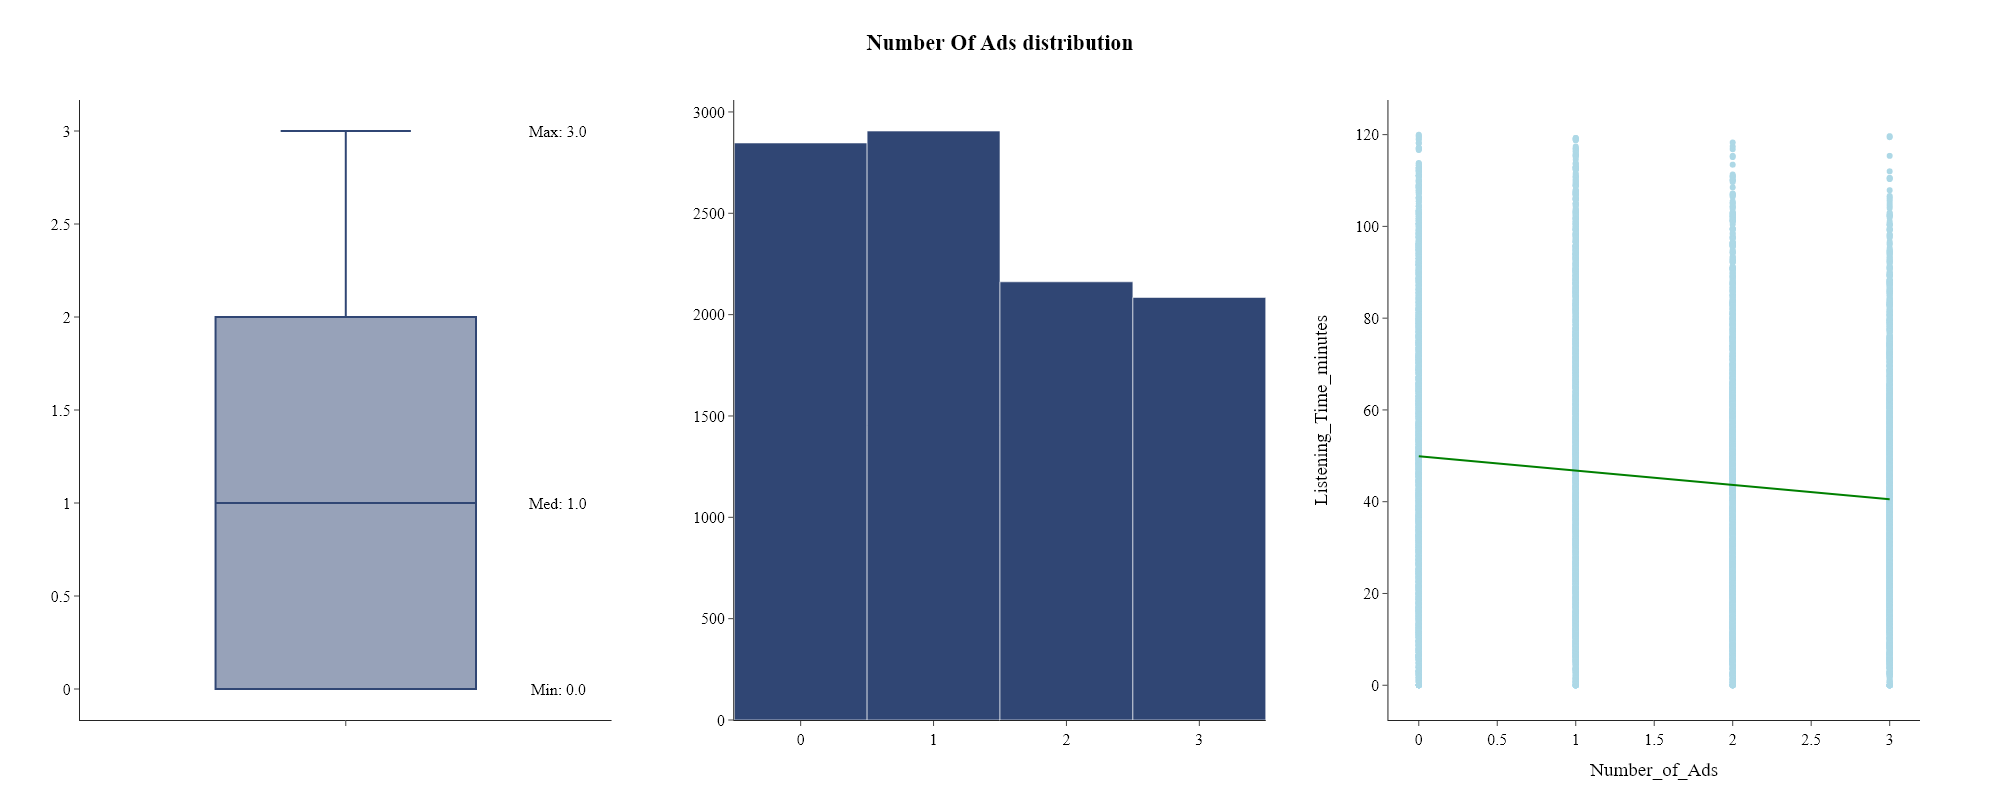

In [36]:
train_data["Number_of_Ads"] = np.clip(train_data["Number_of_Ads"], 0, 4)
test_data["Number_of_Ads"] = np.clip(test_data["Number_of_Ads"], 0, 4)
fillna_value = np.median(np.hstack([train_data["Number_of_Ads"].dropna(), test_data["Number_of_Ads"].dropna()]))
train_data.fillna({"Number_of_Ads": fillna_value}, inplace=True)
test_data.fillna({"Number_of_Ads": fillna_value}, inplace=True)
plots.histogram_boxplot_linear_regression(data=train_data, feature="Number_of_Ads", target="Listening_Time_minutes", name="Number of Ads", annotations=["Min", "Med", "Max"], bin_size=1)

**Conclusion:**
- I will create a new feature called `ads_per_minute` which will represent the number of ads per minute.
- I will convert `Number_of_Ads` to `int` dtype as it is a numerical variable.

In [37]:
train_data["ads_per_minute"] = np.where(train_data["Episode_Length_minutes"] == 0, 0, train_data["Number_of_Ads"] / train_data["Episode_Length_minutes"])
test_data["ads_per_minute"] = np.where(test_data["Episode_Length_minutes"] == 0, 0, test_data["Number_of_Ads"] / test_data["Episode_Length_minutes"])
train_data["Number_of_Ads"] = train_data["Number_of_Ads"].astype("int8")
test_data["Number_of_Ads"] = test_data["Number_of_Ads"].astype("int8")

## `Episode_Sentiment`

`Episode_Sentiment` is the sentiment of the episode.

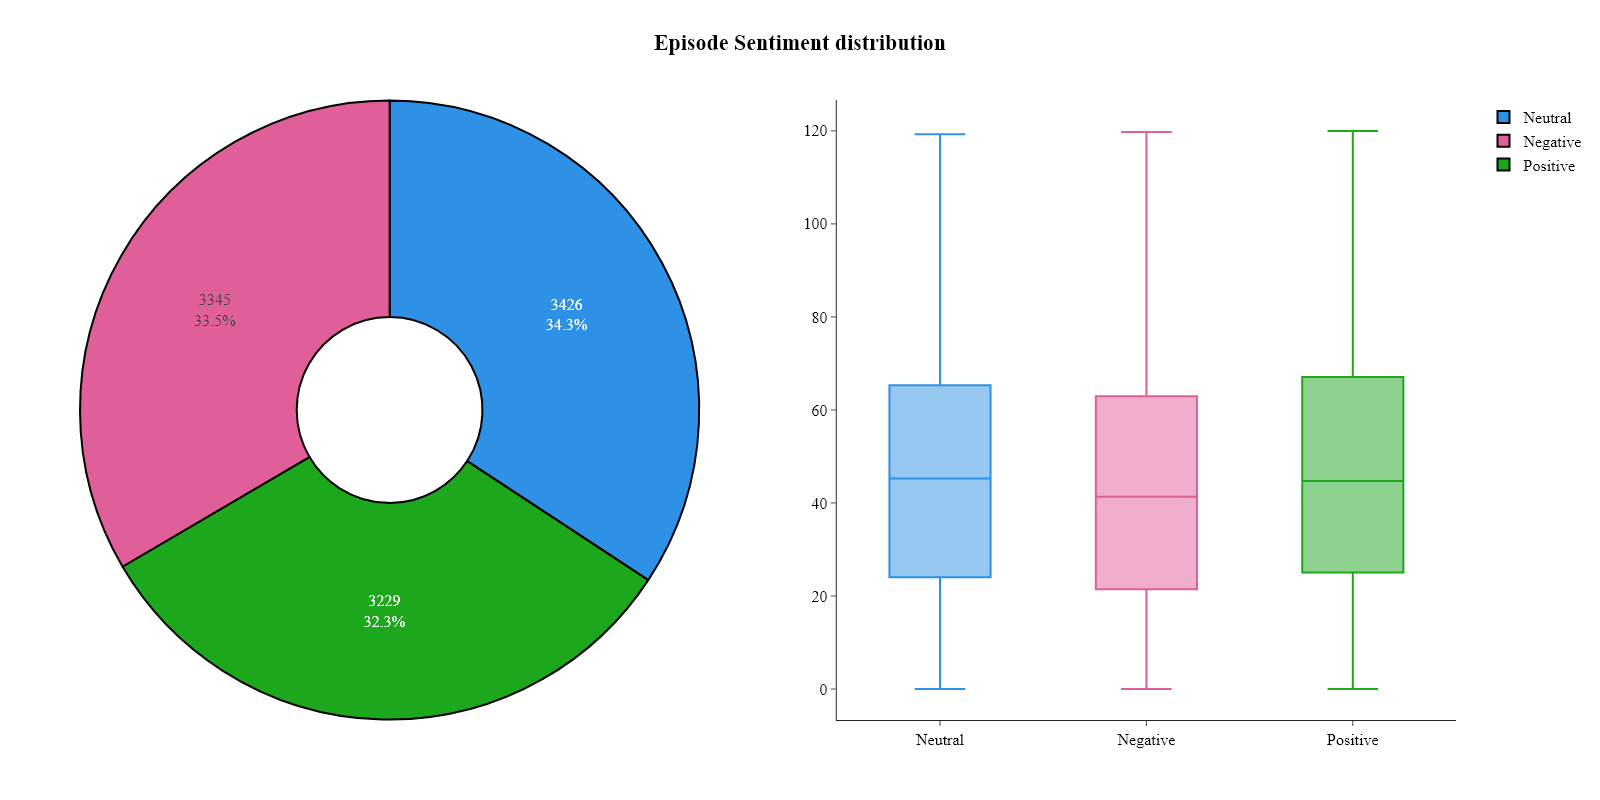

In [38]:
plots.pie_boxplot_by_categorical(train_data, "Episode_Sentiment", "Listening_Time_minutes", "Episode Sentiment")

**Notes:**
- Episode sentiment is a categorical variable with 3 distinct values: `Positive`, `Neutral` and `Negative`.
- The distribution of listening time is pretty similar for all sentiments.

**Conclusion:**
- I will convert the column to `category` dtype as it is a categorical variable (converting to `category` dtype reduces memory usage).

In [39]:
train_data["Episode_Sentiment"] = train_data["Episode_Sentiment"].astype("category")
test_data["Episode_Sentiment"] = test_data["Episode_Sentiment"].astype("category")

## `Listening_Time_minutes`

`Listening_Time_minutes` is the listening time in minutes - the target variable.

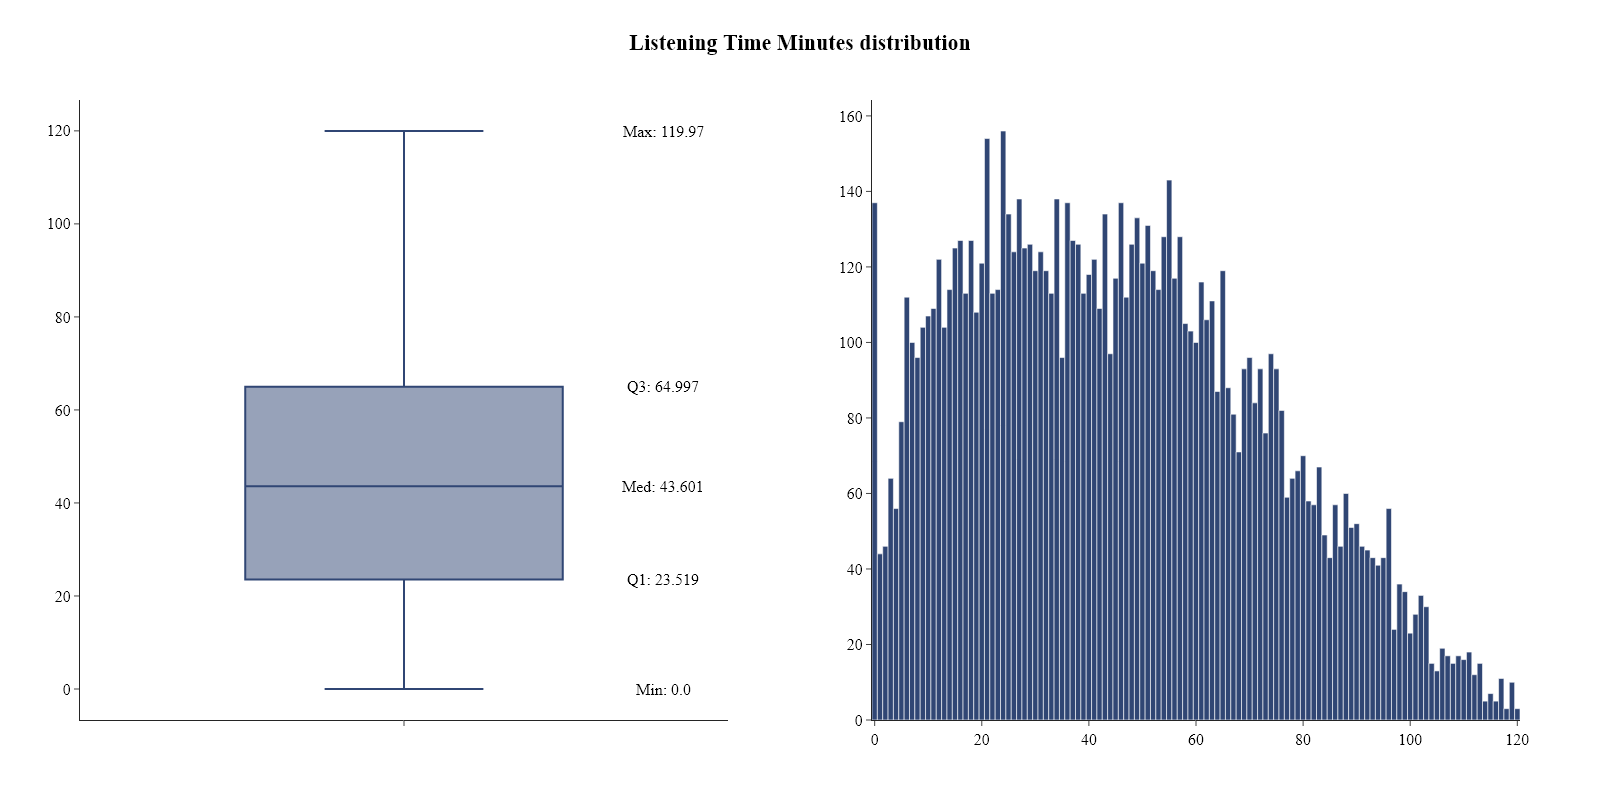

In [40]:
plots.histogram_and_box_plot(data=train_data["Listening_Time_minutes"], name="Listening Time Minutes", annotations=True, bin_size=1)

**Notes:**
- Median of target variables is a little bit higher than 40 minutes.

**Conclusion:**
- I will convert the column to `float` dtype as it is a continuous variable.

In [41]:
train_data["Listening_Time_minutes"] = train_data["Listening_Time_minutes"].astype("float32")

## Summary

In [42]:
categorical_features = train_data.select_dtypes(include=["category"]).columns.tolist()
numerical_features = train_data.select_dtypes(exclude=["category"]).columns.tolist()
independent_features = train_data.columns.difference(["Listening_Time_minutes"]).tolist()
target_feature = "Listening_Time_minutes"
base_information(train_data)

,dtypes,Number of missing values,Percentage of missing values,Unique values,Count
Podcast_Name,category,0,0.000000,48,10000
Episode_Length_minutes,float32,0,0.000000,5320,10000
Genre,category,0,0.000000,10,10000
Host_Popularity_percentage,float32,0,0.000000,5099,10000
Publication_Day,category,0,0.000000,7,10000
Publication_Time,category,0,0.000000,4,10000
Guest_Popularity_percentage,float32,0,0.000000,4950,10000
Number_of_Ads,int8,0,0.000000,4,10000
Episode_Sentiment,category,0,0.000000,3,10000
Listening_Time_minutes,float32,0,0.000000,8687,10000


# Global data analysis

# Numerical data analysis

## Correlation matrix

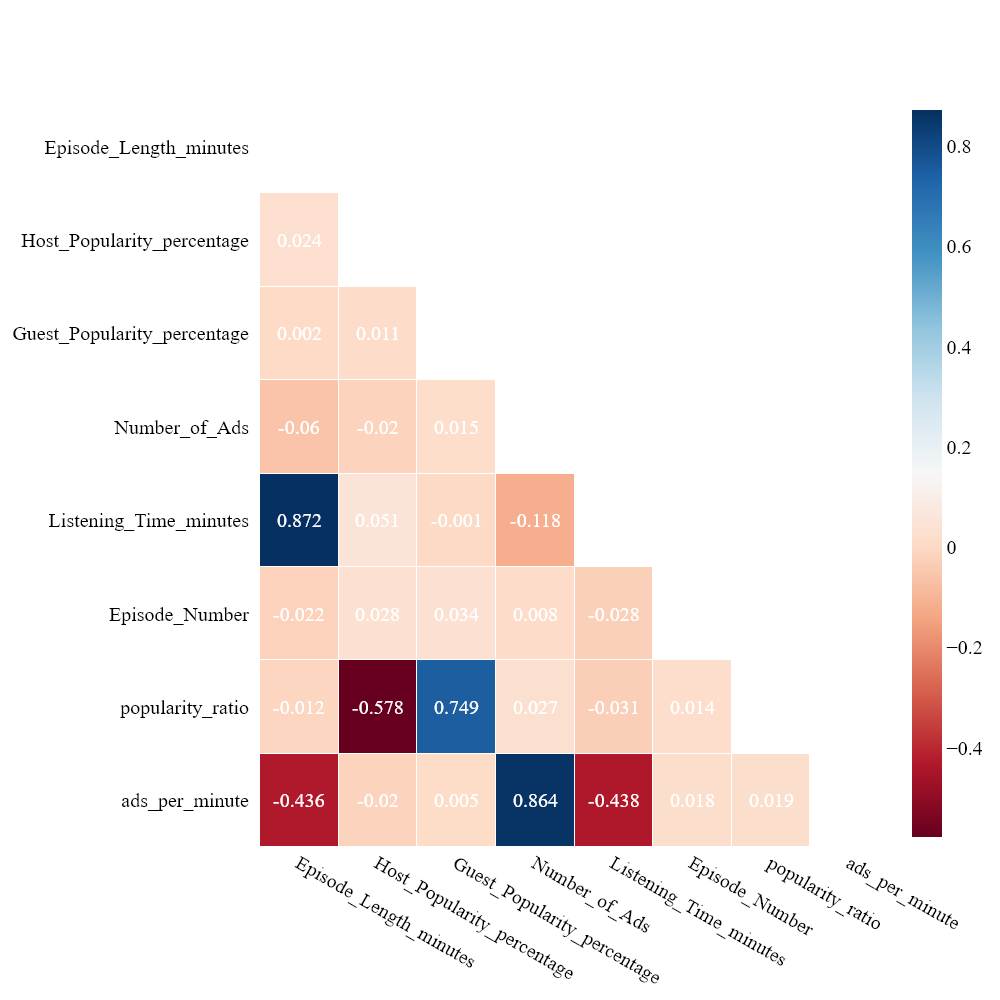

In [43]:
plots.correlation_plot(train_data[numerical_features], features_names=numerical_features, method="spearman")

**Notes:**
- Most correlated features with the target variable is `Episode_Length_minutes`, other features are not correlated with the target variable/the correlation is very low.

## VIF

To check whether multi-collinearity is present in the dataset, we will calculate the Variance Inflation Factor (VIF) for each continuous feature.

In [44]:
vif_data = pd.DataFrame()
vif_data["feature"] = numerical_features
vif_data["VIF"] = [variance_inflation_factor(train_data[numerical_features].values, i) for i in range(len(numerical_features))] 
vif_data.sort_values("VIF", ascending=False, inplace=True)
vif_data.reset_index(drop=True, inplace=True)
vif_data

,feature,VIF
0,Episode_Length_minutes,21.909210
1,Guest_Popularity_percentage,16.724793
2,Listening_Time_minutes,14.950843
3,Host_Popularity_percentage,11.171226
4,popularity_ratio,10.519662
5,Episode_Number,4.003526
6,Number_of_Ads,3.946537
7,ads_per_minute,2.842930


# Categorical data analysis

## Chi square test

Chi square test is used to determine whether there is a significant association between two categorical variables.

Although our target variable is continous, we can create bins and treat it as categorical feature.

Below we will crate a temporary categorical feature based on target variable and then we will use chi square test to check whether there is a significant association between this temporary feature and other categorical features.

The temporary categorized target will have 5 unique values based on quantiles.

In [45]:
train_data_temp = train_data.copy()
train_data_temp[f"{target_feature}_bins"] = pd.qcut(train_data_temp[target_feature], q=5, labels=False)
train_data_temp[f"{target_feature}_bins"].value_counts()

Listening_Time_minutes_bins
0    2001
4    2000
2    2000
3    2000
1    1999
Name: count, dtype: int64

In [46]:
class Chi_Square_Test:
    def check_X(
        self, X: pd.DataFrame | pd.Series | np.ndarray
    ) -> np.ndarray:
        """
        Check if X is pandas DataFrame, pandas Series or numpy array and convert it to numpy array.

        Args:
            X: (pd.DataFrame | pd.Series | np.ndarray): input data.

        Returns:
            X: (np.ndarray): converted input data.
        """
        if (
            not isinstance(X, pd.DataFrame)
            and not isinstance(X, pd.Series)
            and not isinstance(X, np.ndarray)
        ):
            raise TypeError(
                "Wrong type of X. It should be pandas DataFrame, pandas Series, numpy array."
            )
        X = np.array(X)
        if X.ndim == 1:
            X = X[None, :]
        return X

    def check_y(
        self, y: pd.DataFrame | pd.Series | np.ndarray
    ) -> np.ndarray:
        """
        Check if y is pandas DataFrame, pandas Series or numpy array and convert it to numpy array.

        Args:
            y: (pd.DataFrame | pd.Series | np.ndarray): target data.

        Returns:
            y: (np.ndarray): converted target data.
        """
        if (
            not isinstance(y, pd.DataFrame)
            and not isinstance(y, pd.Series)
            and not isinstance(y, np.ndarray)
        ):
            raise TypeError(
                "Wrong type of y. It should be pandas DataFrame, pandas Series, numpy array."
            )
        y = np.array(y)
        if y.ndim != 1:
            y = y.squeeze()
        return y

    def check_for_object_columns(self, X: np.ndarray) -> np.ndarray:
        """
        Check if X contains object columns and convert it to numeric data.

        Args:
            X: (np.ndarray): input data.

        Returns:
            X: (np.ndarray): converted input data.
        """
        X = pd.DataFrame(X)
        if X.select_dtypes(include=np.number).shape[1] != X.shape[1]:
            raise TypeError(
                "Your data contains object or string columns. Numeric data is obligated."
            )
        return np.array(X)

    def fit(
        self,
        X: pd.DataFrame | pd.Series | np.ndarray,
        y: pd.DataFrame | pd.Series | np.ndarray,
        alpha: float = 0.05,
    ):
        """
        Perform Chi Square test.

        Args:
            X: (pd.DataFrame | pd.Series | np.ndarray): input data.
            y: (pd.DataFrame | pd.Series | np.ndarray): target data.
            alpha: (float): significance level.
        """
        # X = self.check_X(X)
        # X = self.check_for_object_columns(X)
        # y = self.check_y(y)
        self.crosstab_ = self.crosstab_creation(X=X, y=y)
        self.check_assumptions(crosstab=self.crosstab_)
        self.test_statistic_ = self.calculate_chi_square_statistic(
            crosstab=self.crosstab_
        )
        self.df_ = self.calculate_degrees_of_freedom(crosstab=self.crosstab_)
        self.p_value_ = self.calculate_p_value(
            test_statistic=self.test_statistic_, df=self.df_
        )
        self.critical_value_ = self.calculate_critical_value(df=self.df_, alpha=alpha)
        self.keep_H0 = self.statistical_inference(p_value=self.p_value_, alpha=alpha)
        self.V_Cramera_ = self.calculate_V_Cramera(
            test_statistic=self.test_statistic_, crosstab=self.crosstab_
        )

    def crosstab_creation(self, X: np.ndarray, y: np.ndarray) -> np.ndarray:
        """
        Create crosstab from input data.

        Args:
            X: (np.ndarray): input data.
            y: (np.ndarray): target data.

        Returns:
            crosstab: (np.ndarray): crosstab.
        """
        return np.array(pd.crosstab(X, y, margins=True))

    def check_assumptions(self, crosstab: np.ndarray) -> bool:
        """
        Check if assumptions for Chi Square test are met.

        Args:
            crosstab: (np.ndarray): crosstab.

        Raises:
            Warning: if assumptions are not met.
        """
        if not all(i <= 5 for i in crosstab.flatten()):
            self.assumption_ = False
            #warnings.warn("Assumptions for Chi Square test are not met.")
        else:
            self.assumption_ = True

    def calculate_chi_square_statistic(self, crosstab: np.ndarray) -> float:
        """
        Calculate Chi Square statistic.

        Args:
            crosstab: (np.ndarray): crosstab.

        Returns:
            chi_square: (float): Chi Square statistic.
        """
        chi_square = 0
        for row in range(0, crosstab.shape[0] - 1):
            for column in range(0, crosstab.shape[1] - 1):
                observed = crosstab[row][column]
                expected = crosstab[row][-1] * crosstab[-1][column] / crosstab[-1][-1]
                chi_square += (observed - expected) ** 2 / expected
        return chi_square

    def calculate_degrees_of_freedom(self, crosstab: np.ndarray) -> int:
        """
        Calculate degrees of freedom.

        Args:
            crosstab: (np.ndarray): crosstab.

        Returns:
            df: (int): degrees of freedom.
        """
        return (crosstab.shape[0] - 2) * (crosstab.shape[1] - 2)

    def calculate_p_value(self, test_statistic: float, df: int) -> float:
        """
        Calculate p value.

        Args:
            test_statistic: (float): test statistic.
            df: (int): degrees of freedom.

        Returns:
            p_value: (float): p value.
        """
        return 1 - chi2.cdf(x=test_statistic, df=df)

    def calculate_critical_value(self, df: int, alpha: float) -> float:
        """
        Calculate critical value.

        Args:
            df: (int): degrees of freedom.
            alpha: (float): significance level.

        Returns:
            critical_value: (float): critical value.
        """
        return chi2.isf(q=alpha, df=df)

    def statistical_inference(self, p_value: float, alpha: float) -> bool:
        """
        Perform statistical inference.

        Args:
            p_value: (float): p value.
            alpha: (float): significance level.

        Returns:
            bool: (bool): True if H0 is not rejected, False otherwise.
        """
        if p_value >= alpha:
            return True
        else:
            return False

    def calculate_V_Cramera(self, test_statistic: float, crosstab: np.ndarray) -> float:
        """
        Calculate V Cramer test statistic.

        Args:
            test_statistic: (float): test statistic.
            crosstab: (np.ndarray): crosstab.

        Returns:
            V_Cramer: (float): V Cramer test statistic.
        """
        return (
            test_statistic
            / (
                crosstab[-1][-1]
                * np.min([crosstab.shape[0] - 2, crosstab.shape[1] - 2])
            )
        ) ** 0.5

chi_square = Chi_Square_Test()

In [47]:
chi_square_results = pd.DataFrame(columns=["Feature", "p_value", "Test statistic", "Critical value", "H0 rejected", "V Cramera"])
for feature in categorical_features:
    chi_square.fit(X=train_data_temp[feature], y=train_data_temp[f"{target_feature}_bins"])
    chi_square_results = pd.concat([chi_square_results if not chi_square_results.empty else None, pd.DataFrame({"Feature": [feature], "p_value": [chi_square.p_value_], "Test statistic": [chi_square.test_statistic_], "Critical value": [chi_square.critical_value_], "H0 rejected": [not chi_square.keep_H0], "V Cramera": [chi_square.V_Cramera_]})])
chi_square_results.sort_values(by="Test statistic", ascending=False, inplace=True)
chi_square_results.reset_index(drop=True, inplace=True)
print(f"Percantage of features where H0 is not rejected (features are NOT associated with {target_feature}): {chi_square_results[chi_square_results['H0 rejected'] == False].shape[0]/len(chi_square_results)*100:.2f}%")
print(f"Percantage of features where H0 is rejected (features are associated with {target_feature}): {chi_square_results[chi_square_results['H0 rejected'] == True].shape[0]/len(chi_square_results)*100:.2f}%")
chi_square_results

Percantage of features where H0 is not rejected (features are NOT associated with Listening_Time_minutes): 37.50%
Percantage of features where H0 is rejected (features are associated with Listening_Time_minutes): 62.50%


,Feature,p_value,Test statistic,Critical value,H0 rejected,V Cramera
0,Podcast_Name,0.009057,236.860229,220.990822,True,0.076951
1,Genre,0.011974,57.823595,50.998460,True,0.038021
2,Episode_Sentiment,0.000030,34.716324,15.507313,True,0.041663
3,Episode_Length_minutes_Imputed,0.000005,30.172940,9.487729,True,0.054930
4,Publication_Day,0.327733,26.511495,36.415029,False,0.025745
5,Publication_Time,0.015017,24.959327,21.026070,True,0.028844
6,Guest_Popularity_percentage_Imputed,0.543954,3.083475,9.487729,False,0.017560
7,is_weekend,0.703429,2.175981,9.487729,False,0.014751


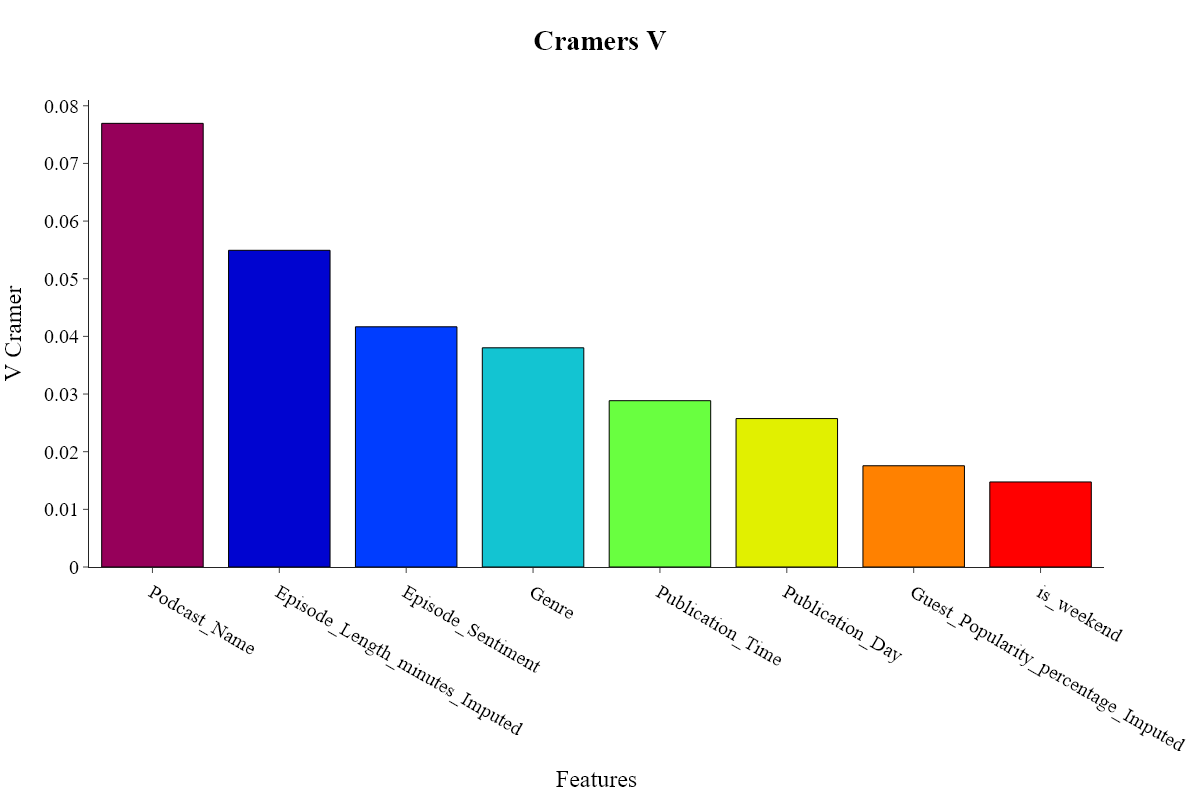

In [48]:
chi_square_results_sorted = chi_square_results.sort_values(by="V Cramera", ascending=False)
fig = go.Figure()
n_colors = len(chi_square_results_sorted)
colors = px.colors.sample_colorscale("rainbow", [n/(n_colors - 1) for n in range(n_colors)])
fig.add_trace(go.Bar(x=chi_square_results_sorted["Feature"], y=chi_square_results_sorted["V Cramera"], marker=dict(color=colors, line=dict(color='black', width=1), line_color='black')))
fig.update_xaxes(title_text="Features")
fig.update_yaxes(title_text="V Cramer")
fig.update_layout(template="simple_white", width=1200, height=800, title="<b>Cramers V<b>", title_x=0.5, font=dict(family="Times New Roman", size=20, color="Black"))
fig.show("png")

**Notes:**
- The highest Cramer's V for binned target variable is with `Number_of_Ads`.
- Cramer's V values are pretty low for all features which means that there is no strong association between the target variable and other categorical features.

**Conclusion:**
- We will drop binned target variable after this analysis.

In [49]:
train_data_temp.drop(f"{target_feature}_bins", axis=1, inplace=True)

# All features

## Mutual information

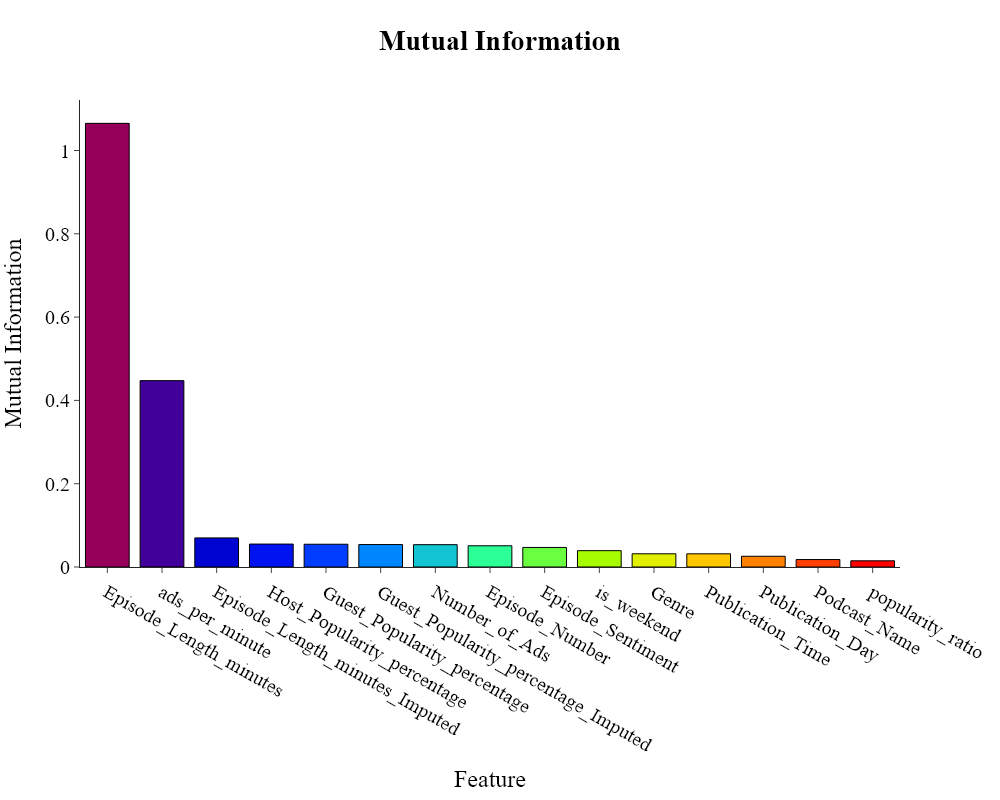

In [50]:
ordinal_encoder = OrdinalEncoder()
train_data_temp[categorical_features] = ordinal_encoder.fit_transform(train_data_temp[categorical_features])
mi_scores = {}
for feature in independent_features:
    if feature in categorical_features:
        mi_scores[feature] = mutual_info_regression(train_data_temp[[feature]], train_data_temp[target_feature], random_state=SEED, discrete_features=True)[0]
    else:
        mi_scores[feature] = mutual_info_regression(train_data_temp[[feature]], train_data_temp[target_feature], random_state=SEED)[0]
mi_scores = {k: v for k, v in sorted(mi_scores.items(), key=lambda item: item[1], reverse=True)}
fig = go.Figure()
n_colors = len(mi_scores)
colors = px.colors.sample_colorscale("rainbow", [n/(n_colors -1) for n in range(n_colors)])
fig.add_trace(go.Bar(x=list(mi_scores.keys()), y=list(mi_scores.values()), marker=dict(color=colors, line=dict(color='black', width=1), line_color='black')))
fig.update_layout(template="simple_white", width=1000, height=800, title="<b>Mutual Information<b>", title_x=0.5, xaxis_title="Feature", yaxis_title=f"Mutual Information", font=dict(family="Times New Roman",size=20,color="Black"), showlegend=False)
fig.show("png")

**Notes:**
- As expected the highest mutual information is with `Episode_Length_minutes` which was expected as it is the most correlated feature with the target variable.

## Outliers

Before applying Isolation Forest we will convert categorical features with the usage of pandas `get_dummies` function.

In [51]:
train_data_temp = train_data.copy()
train_data_temp = pd.get_dummies(train_data_temp, columns=categorical_features, drop_first=True)
train_data_temp.drop(target_feature, axis=1, inplace=True)

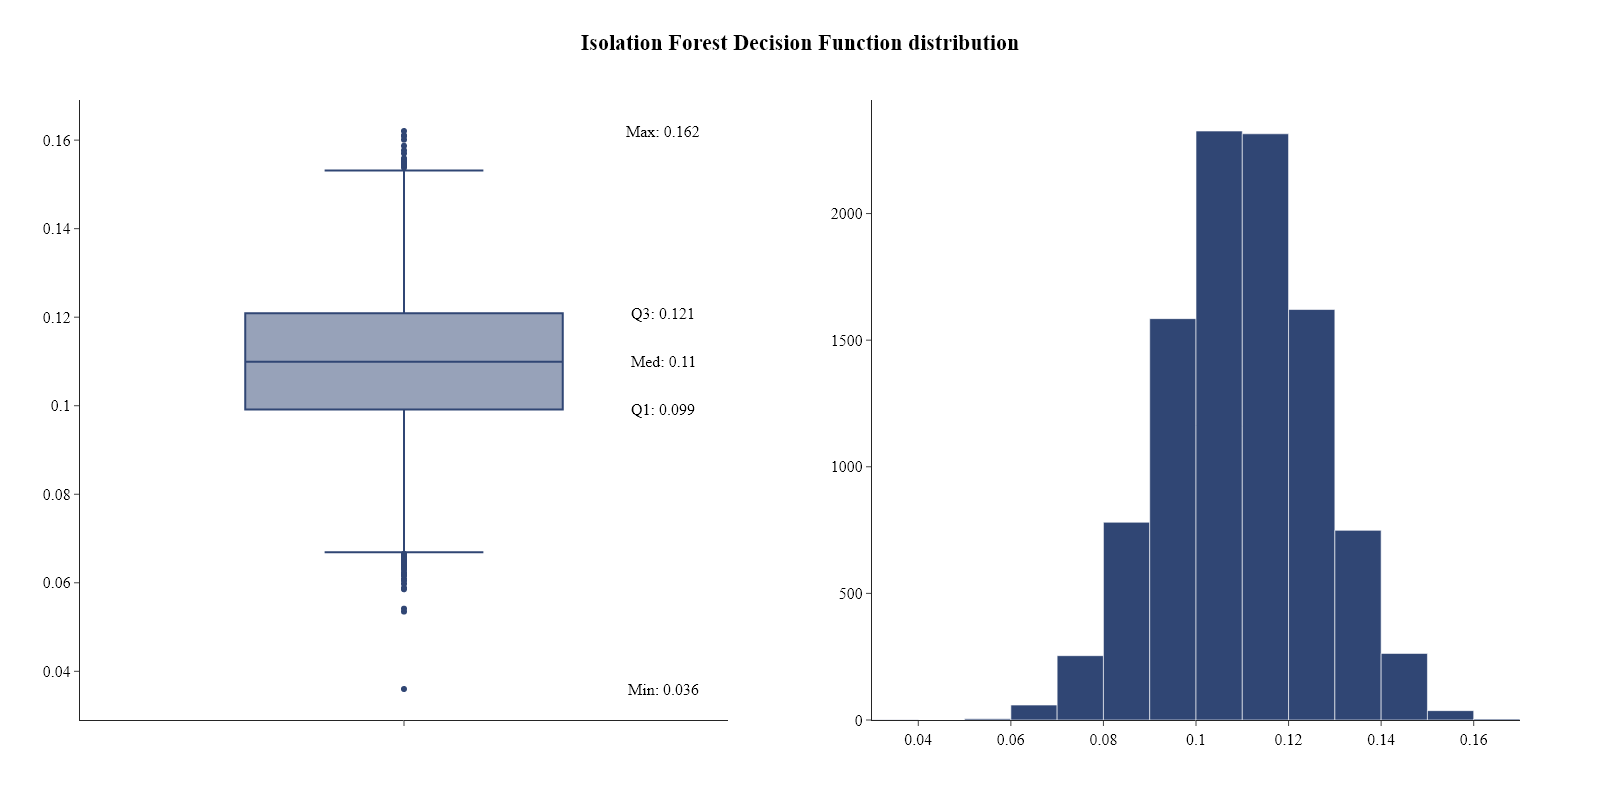

Number of outliers: 0.
Proportion of outliers: 0.0%.


In [52]:
isolation_forest = IsolationForest(random_state=SEED, n_jobs=-1)
isolation_forest.fit(train_data_temp)
plots.histogram_and_box_plot(data=isolation_forest.decision_function(train_data_temp), name="Isolation Forest Decision Function", annotations=True, bin_size=0.01)
outliers = isolation_forest.predict(train_data_temp)
outliers = pd.Series(outliers)
print("Number of outliers: {}.".format(outliers[outliers == -1].shape[0]))
print("Proportion of outliers: {}%.".format(np.round(outliers[outliers == -1].shape[0] / train_data_temp.shape[0] * 100, 2)))

Before UMAP which is time consuming I will limit dataset to 10k observations.

In [53]:
train_data_temp = train_data_temp.sample(min(train_data_temp.shape[0], 10000))
outliers = isolation_forest.predict(train_data_temp)
outliers = pd.Series(outliers)

C:\Users\Kuba\AppData\Roaming\Python\Python311\site-packages\sklearn\utils\deprecation.py:151: FutureWarning:

'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.

C:\Users\Kuba\AppData\Roaming\Python\Python311\site-packages\umap\umap_.py:1943: UserWarning:

n_jobs value -1 overridden to 1 by setting random_state. Use no seed for parallelism.



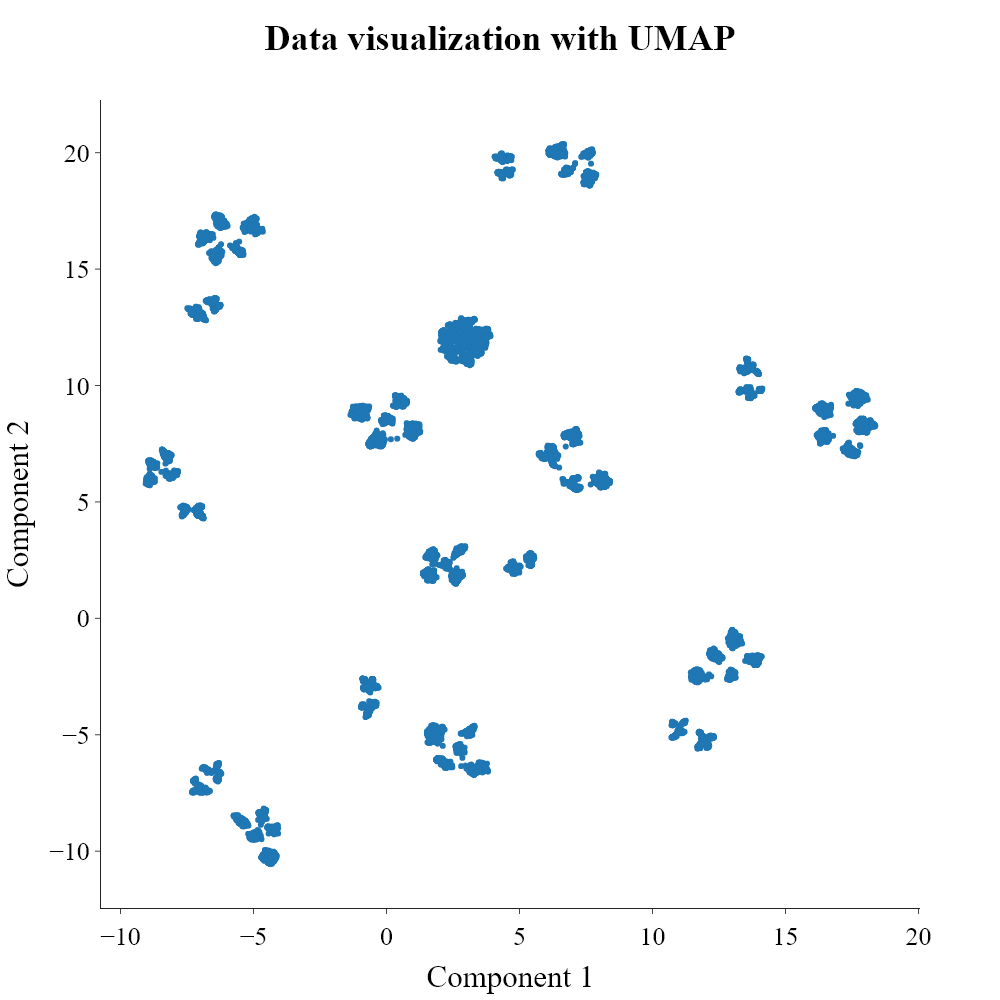

In [54]:
scaler = MinMaxScaler()
umap_model = UMAP(n_components=2, random_state=SEED, n_jobs=-1)
train_data_temp_scaled = scaler.fit_transform(train_data_temp)
X_umap = umap_model.fit_transform(train_data_temp_scaled)
plots.scatter_plot(data=X_umap, hue=outliers, hue_name="Outliers", name="Data visualization with UMAP")

**Notes:**
- We can clearly see clusters in the data.
- Because the count of the clusters is 10 I will check the plot with Genre as hue.

In [55]:
train_data_temp["Genre"] = train_data.loc[train_data_temp.index, "Genre"].values

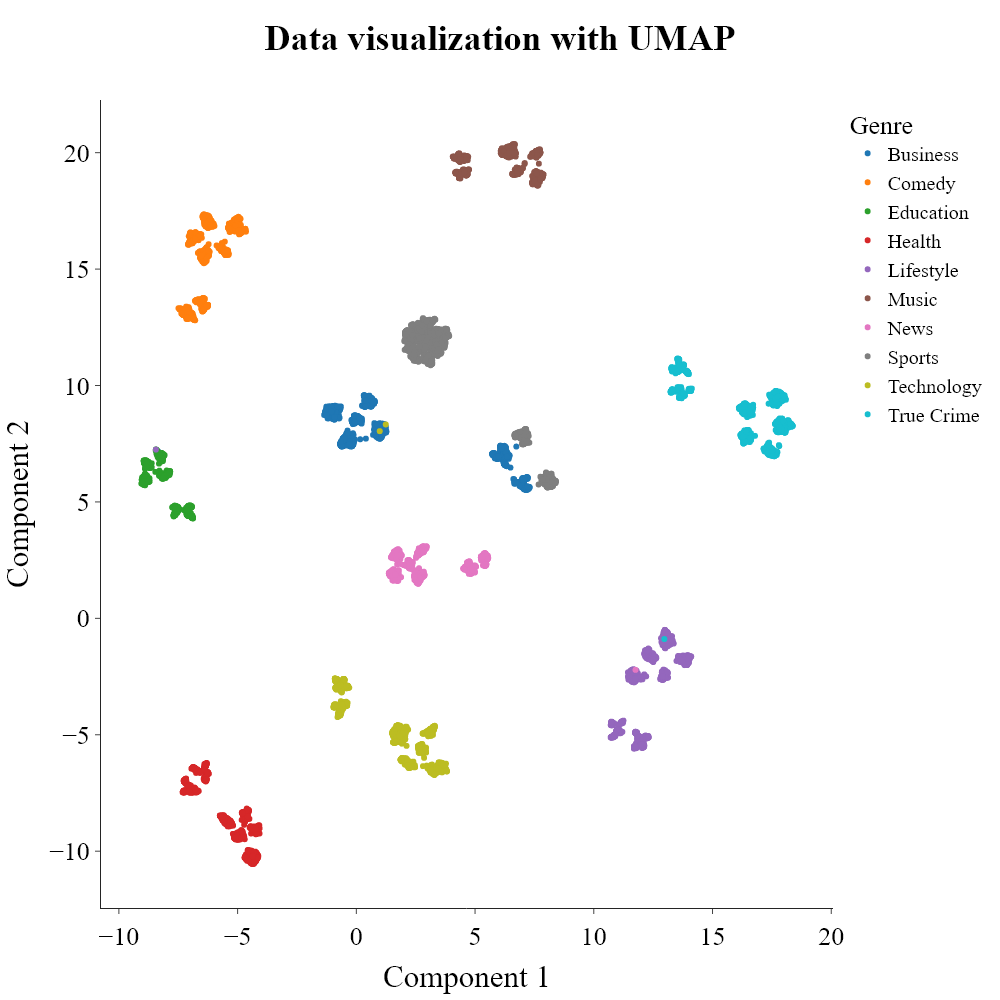

In [56]:
plots.scatter_plot(data=X_umap, hue=train_data_temp["Genre"], hue_name="Genre", name="Data visualization with UMAP")

**Notes:**
- We can see that clusters are well seperated by the `Genre` feature.

In [57]:
del train_data_temp, train_data_temp_scaled

# Modeling

## Base models

### LightGBM

In [58]:
model = LGBMRegressor(random_state=SEED, verbose=-1, n_jobs=-1, objective='regression', metric=compare_metric_name, linear_tree=True)
train_scores, validation_scores = perform_cv(train_data[independent_features], train_data[target_feature], model, cv=KFold(n_splits=5, shuffle=True, random_state=SEED), metric=root_mean_squared_error)
print(f"Train {compare_metric_name}: {np.mean(train_scores):.4f} +- {np.std(train_scores):.4f}")
print(f"Validation {compare_metric_name}: {np.mean(validation_scores):.4f} +- {np.std(validation_scores):.4f}")

Train RMSE: 9.2410 +- 0.0541
Validation RMSE: 14.2537 +- 0.4016


### XGBoost

In [59]:
model = XGBRegressor(random_state=SEED, n_jobs=-1, objective='reg:squarederror', enable_categorical=True, tree_method='hist')
train_scores, validation_scores = perform_cv(train_data[independent_features], train_data[target_feature], model, cv=KFold(n_splits=5, shuffle=True, random_state=SEED), metric=root_mean_squared_error)
print(f"Train {compare_metric_name}: {np.mean(train_scores):.4f} +- {np.std(train_scores):.4f}")
print(f"Validation {compare_metric_name}: {np.mean(validation_scores):.4f} +- {np.std(validation_scores):.4f}")

Train RMSE: 4.4766 +- 0.1036
Validation RMSE: 15.2721 +- 0.2504


### Histogram-based Gradient Boosting

In [60]:
model = HistGradientBoostingRegressor(random_state=SEED, categorical_features=categorical_features)
train_scores, validation_scores = perform_cv(train_data[independent_features], train_data[target_feature], model, cv=KFold(n_splits=5, shuffle=True, random_state=SEED), metric=root_mean_squared_error)
print(f"Train {compare_metric_name}: {np.mean(train_scores):.4f} +- {np.std(train_scores):.4f}")
print(f"Validation {compare_metric_name}: {np.mean(validation_scores):.4f} +- {np.std(validation_scores):.4f}")

Train RMSE: 9.9618 +- 0.0523
Validation RMSE: 14.2248 +- 0.2696


### Stacking

In [61]:
estimators = [
    ('lightgbm', LGBMRegressor(random_state=SEED, n_jobs=-1, verbose=0, objective='regression', metric=compare_metric_name, linear_tree=False)),
    ('xgboost', XGBRegressor(random_state=SEED, n_jobs=-1, verbose=0, objective='reg:squarederror', enable_categorical=True, tree_method='hist')),
    ('hist_gradient_boosting', HistGradientBoostingRegressor(random_state=SEED, categorical_features=categorical_features)),
]
stacking_model = StackingRegressor(estimators=estimators, final_estimator=ElasticNetCV(random_state=SEED), cv=KFold(n_splits=5, shuffle=True, random_state=SEED), n_jobs=-1)
train_scores, validation_scores = perform_cv(train_data[independent_features], train_data[target_feature], stacking_model, cv=KFold(n_splits=5, shuffle=True, random_state=SEED), metric=root_mean_squared_error)
print(f"Train {compare_metric_name}: {np.mean(train_scores):.4f} +- {np.std(train_scores):.4f}")
print(f"Validation {compare_metric_name}: {np.mean(validation_scores):.4f} +- {np.std(validation_scores):.4f}")

Train RMSE: 10.2332 +- 0.2020
Validation RMSE: 14.1170 +- 0.2648


**Notes:**
- We can see that stacking model is performing slightly better (in terms of validation score) than base models.

## Hyperparameter tuning

In [62]:
class RandomSearchCV:
    def __init__(
        self,
        algorithm: object,
        metric: str,
        cv: sklearn.model_selection.BaseCrossValidator = KFold(n_splits=5, shuffle=True, random_state=17),
        n_trials: int = 100,
        seed: int = 17,
        gap_weight: float = 0.3,
    ):
        self.algorithm = algorithm
        self.cv = cv
        self.n_trials = n_trials
        self.seed = seed
        self.gap_weight = gap_weight

        self.metrics = {
            "accuracy": [accuracy_score, "preds", "maximize"],
            "roc_auc": [roc_auc_score, "probs", "maximize"],
            "mse": [mean_squared_error, "preds", "minimize"],
            "rmse": [root_mean_squared_error, "preds", "minimize"],
            "mae": [mean_absolute_error, "preds", "minimize"],
        }

        if metric not in self.metrics:
            raise ValueError(f"Unsupported metric: {metric}")

        self.eval_metric = self.metrics[metric][0]
        self.metric_type = self.metrics[metric][1]
        self.direction = self.metrics[metric][2]

    def tune(
        self,
        X: pd.DataFrame,
        y: pd.Series,
        params_grid: dict[str, tuple[str, list[object]]],
        X_valid: pd.DataFrame = None,
        y_valid: pd.Series = None,
    ) -> optuna.study.Study:
        self.params_grid = params_grid
        study = self.create_study()
        X, y = self.check_X(X), self.check_y(y)
        if X_valid is not None and y_valid is not None:
            X_valid = self.check_X(X_valid)
            y_valid = self.check_y(y_valid)
            study.optimize(lambda trial: self.objective(trial, X, y, X_valid, y_valid), n_trials=self.n_trials)
        else:
            study.optimize(lambda trial: self.objective_cv(trial, X, y), n_trials=self.n_trials)
        return study

    def create_study(self) -> optuna.study.Study:
        sampler = optuna.samplers.TPESampler(seed=self.seed)
        return optuna.create_study(
            direction=self.direction,
            sampler=sampler,
            study_name="Optuna tuning"
        )

    def get_param(self, trial: optuna.Trial, param_name: str, param_values: tuple[str, list[object]]) -> object:
        param_type, param_value = param_values
        if param_type == "int":
            return trial.suggest_int(param_name, *param_value)
        elif param_type == "float":
            return trial.suggest_float(param_name, *param_value, log=True)
        elif param_type == "categorical":
            return trial.suggest_categorical(param_name, param_value)
        elif param_type == "constant":
            return param_value[0]

    def objective(self, trial: optuna.Trial, X_train: pd.DataFrame, y_train: pd.Series, X_valid: pd.DataFrame, y_valid: pd.Series) -> float:
        params = {k: self.get_param(trial, k, v) for k, v in self.params_grid.items()}
        model = self.algorithm.set_params(**params)
        model.fit(X_train, y_train)
        preds = model.predict(X_valid) if self.metric_type == "preds" else model.predict_proba(X_valid)[:, 1]
        return self.eval_metric(y_valid, preds)

    def objective_cv(self, trial: optuna.Trial, X: pd.DataFrame, y: pd.Series) -> float:
        params = {k: self.get_param(trial, k, v) for k, v in self.params_grid.items()}
        # self.algorithm.set_params(**params)
        self.algorithm = self.algorithm.__class__(**params)

        valid_scores = []

        for train_idx, valid_idx in self.cv.split(X):
            X_train, X_valid = X.iloc[train_idx], X.iloc[valid_idx]
            y_train, y_valid = y.iloc[train_idx], y.iloc[valid_idx]
            self.algorithm.fit(X_train,y_train)
            y_valid_pred = self.algorithm.predict(X_valid) if self.metric_type == "preds" else self.algorithm.predict_proba(X_valid)[:, 1]
            valid_scores.append(self.eval_metric(y_valid, y_valid_pred))

        mean_valid = np.mean(valid_scores)
        return mean_valid

    @staticmethod
    def check_X(X: object) -> pd.DataFrame:
        return X if isinstance(X, pd.DataFrame) else pd.DataFrame(X)

    @staticmethod
    def check_y(y: object) -> pd.Series:
        return y if isinstance(y, pd.Series) else pd.Series(y)

### LightGBM

In [63]:
model = LGBMRegressor()
cv = RandomSearchCV(
    algorithm=model,
    metric="rmse",
    cv=KFold(n_splits=5, shuffle=True, random_state=SEED),
    n_trials=N_TRIALS,
    seed=SEED
)
params_grid = {
    "objective": ("constant", ["regression"]),
    "metric": ("constant", [compare_metric_name]),
    "linear_tree": ("constant", [True]),
    "seed": ("constant", [SEED]),
    "verbose": ("constant", [-1]),
    "n_jobs": ("constant", [-1]),
    "boosting_type": ("constant", ["gbdt"]),
    "n_estimators": ("int", [50, 1000]),
    "num_leaves": ("int", [10, 450]),
    "min_child_samples": ("int", [10, 300]),
    "max_depth": ("int", [3, 30]),
    "subsample": ("float", [0.3, 1]),
    "colsample_bytree": ("float", [0.3, 1]),
    "learning_rate": ("float", [1e-3, 0.5]),
    "reg_alpha": ("float", [1e-3, 30]),
    "reg_lambda": ("float", [1e-3, 30]),
    "linear_lambda": ("float", [1e-3, 30]),
}

study = cv.tune(
    train_data[independent_features],
    train_data[target_feature],
    params_grid
)

[I 2025-04-28 22:32:04,777] A new study created in memory with name: Optuna tuning
[I 2025-04-28 22:32:05,822] Trial 0 finished with value: 13.92000902609119 and parameters: {'n_estimators': 330, 'num_leaves': 243, 'min_child_samples': 65, 'max_depth': 4, 'subsample': 0.7737830722497602, 'colsample_bytree': 0.6611562428979949, 'learning_rate': 0.05255932457101159, 'reg_alpha': 0.37761040255451583, 'reg_lambda': 0.0014958547068972478, 'linear_lambda': 0.03999216300149093}. Best is trial 0 with value: 13.92000902609119.
[I 2025-04-28 22:32:11,220] Trial 1 finished with value: 14.325352521229087 and parameters: {'n_estimators': 949, 'num_leaves': 36, 'min_child_samples': 261, 'max_depth': 27, 'subsample': 0.31907247004783607, 'colsample_bytree': 0.6580472549057305, 'learning_rate': 0.030843268446461337, 'reg_alpha': 0.4733030314189369, 'reg_lambda': 0.1461558763011785, 'linear_lambda': 0.01849150715170984}. Best is trial 0 with value: 13.92000902609119.
[I 2025-04-28 22:32:14,050] Trial 2

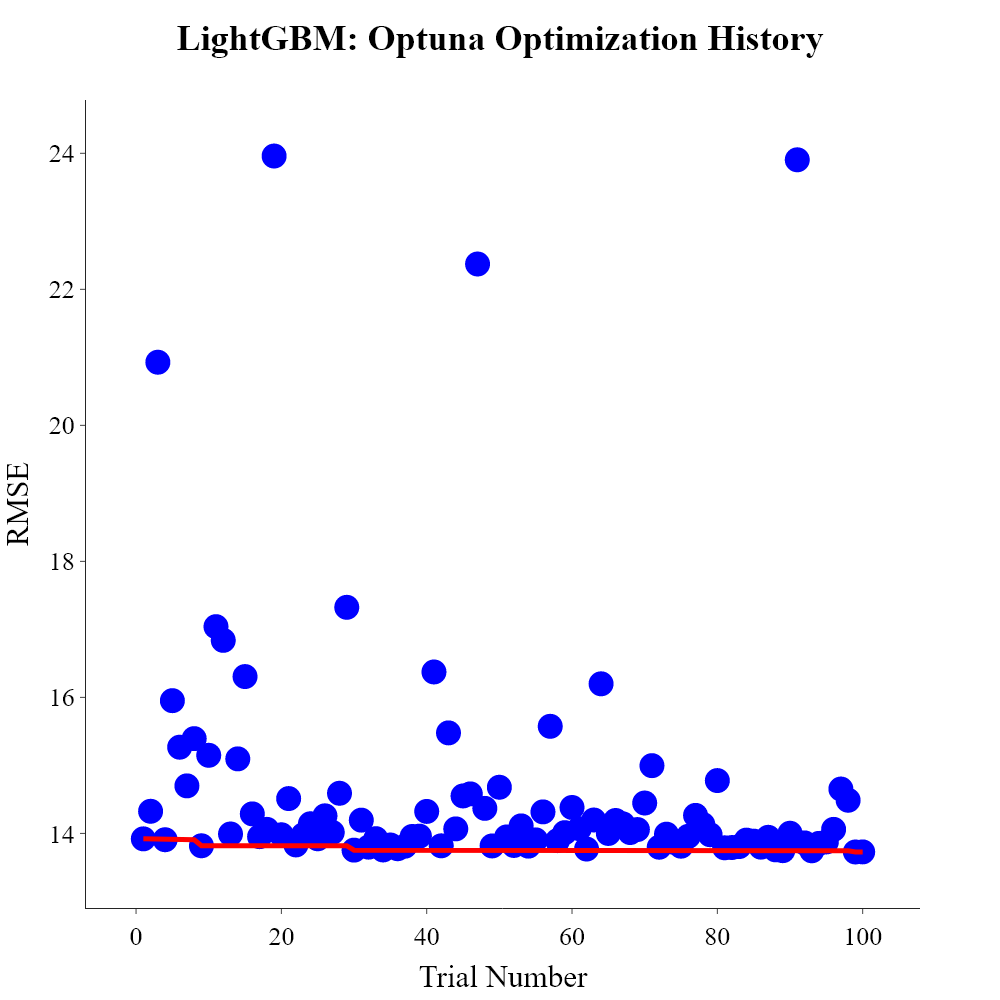

In [64]:
scores = study.trials_dataframe()
fig = go.Figure()
scores.index = scores.index + 1
fig.add_trace(go.Scatter(x=scores.index, y=scores["value"], mode="markers", name="Trial Score", marker=dict(size=25, color="blue"), showlegend=False))
minimum_scores = []
for i in range(len(scores)):
    minimum_scores.append(scores.loc[:i+1, "value"].min())
fig.add_trace(go.Scatter(x=scores.index, y=minimum_scores, mode="lines", name="Minimum Score", line=dict(color="red", width=5), showlegend=False))
fig.update_layout(template="simple_white", width=1000, height=1000, title="<b>LightGBM: Optuna Optimization History<b>", title_x=0.5, xaxis_title="Trial Number", yaxis_title=compare_metric_name, font=dict(family="Times New Roman",size=26,color="Black"), showlegend=False)
fig.show("png")

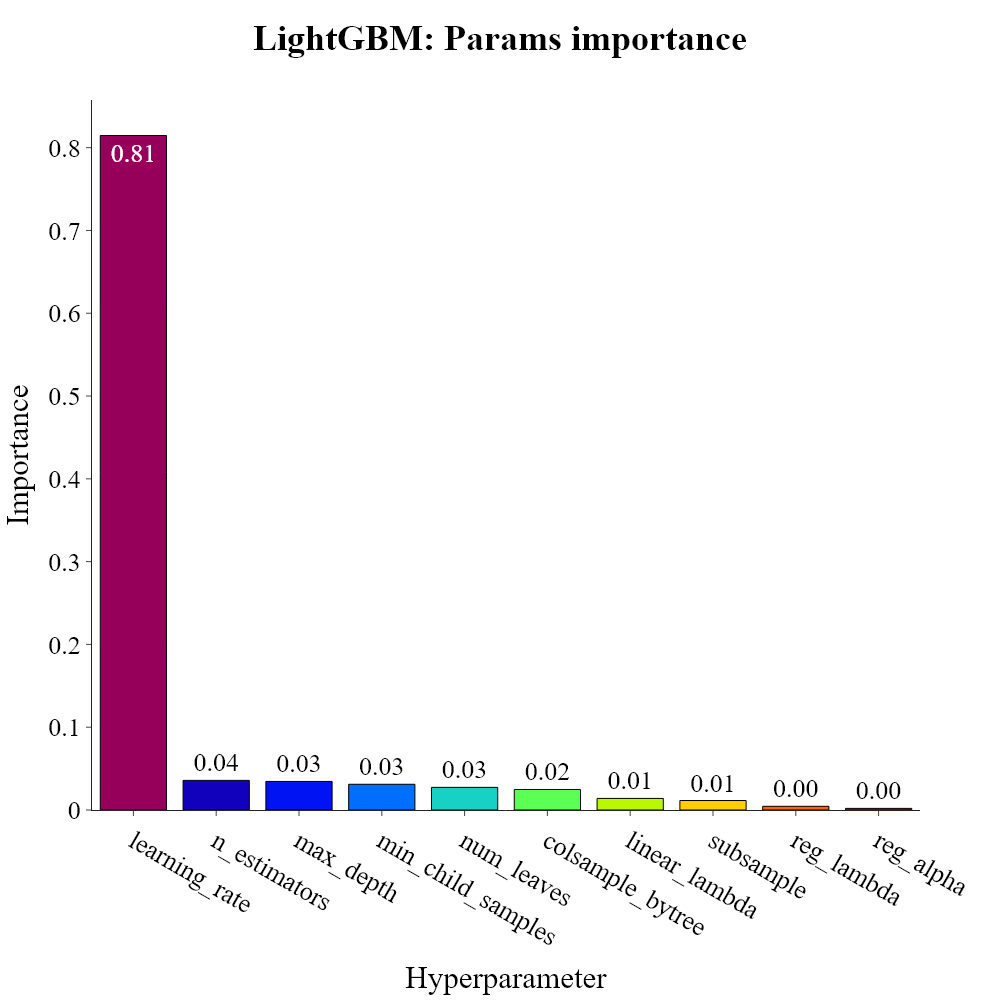

In [65]:
importances = optuna.importance.get_param_importances(study)
fig = go.Figure()
n_colors = len(importances)
colors = px.colors.sample_colorscale("rainbow", [n/(n_colors -1) for n in range(n_colors)])
fig.add_trace(go.Bar(x=list(importances.keys()), y=list(importances.values()), marker=dict(color=colors, line=dict(color='black', width=1), line_color='black'), text=[f"{v:.2f}" for v in list(importances.values())], textposition="auto"))
fig.update_layout(template="simple_white", width=1000, height=1000, title="<b>LightGBM: Params importance<b>", title_x=0.5, xaxis_title="Hyperparameter", yaxis_title=f"Importance", font=dict(family="Times New Roman",size=26,color="Black"), showlegend=False)
fig.show("png")

In [66]:
lgbm_best_params = study.best_trial.params
model = LGBMRegressor(**lgbm_best_params, random_state=SEED, n_jobs=-1, objective='regression', metric=compare_metric_name, linear_tree=True)
train_scores, validation_scores = perform_cv(train_data[independent_features], train_data[target_feature], model, cv=KFold(n_splits=5, shuffle=True, random_state=SEED), metric=root_mean_squared_error)
print(f"Train {compare_metric_name}: {np.mean(train_scores):.4f} +- {np.std(train_scores):.4f}")
print(f"Validation {compare_metric_name}: {np.mean(validation_scores):.4f} +- {np.std(validation_scores):.4f}")

Train RMSE: 12.9717 +- 0.0703
Validation RMSE: 13.7271 +- 0.2446


### XGBoost

In [67]:
model = XGBRegressor()
cv = RandomSearchCV(
    algorithm=model,
    metric="rmse",
    cv=KFold(n_splits=5, shuffle=True, random_state=SEED),
    n_trials=N_TRIALS,
    seed=SEED
)
params_grid = {
    "objective": ("constant", ["reg:squarederror"]),
    "seed": ("constant", [SEED]),
    "n_jobs": ("constant", [-1]),
    "booster": ("constant", ["gbtree"]),
    "tree_method": ("constant", ["hist"]),
    "enable_categorical": ("constant", [True]),
    "n_estimators": ("int", [50, 1000]),
    "max_depth": ("int", [3, 30]),
    "learning_rate": ("float", [1e-3, 0.5]),
    "subsample": ("float", [0.3, 1]),
    "colsample_bytree": ("float", [0.3, 1]),
    "colsample_bylevel": ("float", [0.3, 1]),
    "colsample_bynode": ("float", [0.3, 1]),
    "reg_alpha": ("float", [1e-3, 30]),
    "reg_lambda": ("float", [1e-3, 30]),
    "gamma": ("float", [1e-3, 30]),
    "tree_method": ("constant", ["hist"]),
}
study = cv.tune(
    train_data[independent_features],
    train_data[target_feature],
    params_grid
)

[I 2025-04-28 22:34:48,193] A new study created in memory with name: Optuna tuning
[I 2025-04-28 22:35:04,049] Trial 0 finished with value: 17.39176025390625 and parameters: {'n_estimators': 330, 'max_depth': 17, 'learning_rate': 0.003287826254788394, 'subsample': 0.3255554040575356, 'colsample_bytree': 0.7737830722497602, 'colsample_bylevel': 0.6611562428979949, 'colsample_bynode': 0.6463494460474463, 'reg_alpha': 0.37761040255451583, 'reg_lambda': 0.0014958547068972478, 'gamma': 0.03999216300149093}. Best is trial 0 with value: 17.39176025390625.
[I 2025-04-28 22:35:06,507] Trial 1 finished with value: 14.908390426635743 and parameters: {'n_estimators': 949, 'max_depth': 4, 'learning_rate': 0.2147947785850581, 'subsample': 0.8626563515456908, 'colsample_bytree': 0.31907247004783607, 'colsample_bylevel': 0.6580472549057305, 'colsample_bynode': 0.5829352503057804, 'reg_alpha': 0.4733030314189369, 'reg_lambda': 0.1461558763011785, 'gamma': 0.01849150715170984}. Best is trial 1 with valu

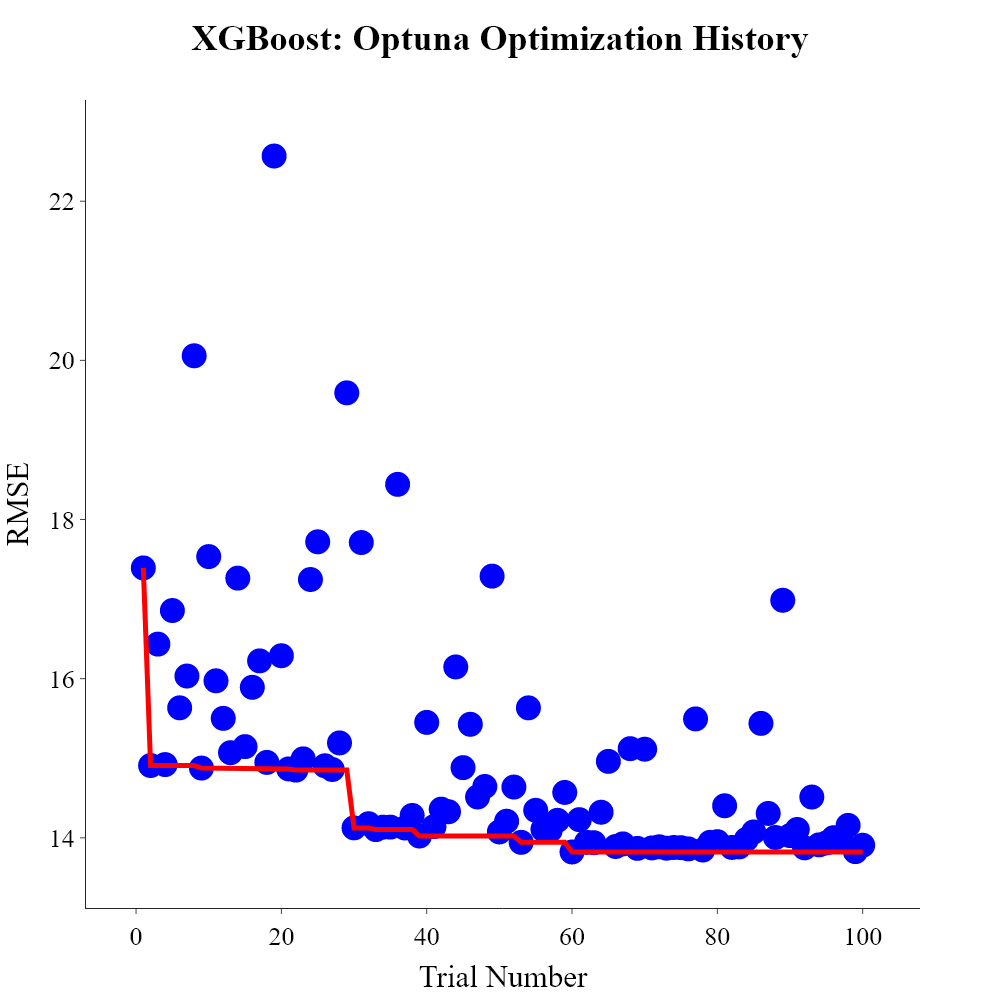

In [68]:
scores = study.trials_dataframe()
fig = go.Figure()
scores.index = scores.index + 1
fig.add_trace(go.Scatter(x=scores.index, y=scores["value"], mode="markers", name="Trial Score", marker=dict(size=25, color="blue"), showlegend=False))
minimum_scores = []
for i in range(len(scores)):
    minimum_scores.append(scores.loc[:i+1, "value"].min())
fig.add_trace(go.Scatter(x=scores.index, y=minimum_scores, mode="lines", name="Minimum Score", line=dict(color="red", width=5), showlegend=False))
fig.update_layout(template="simple_white", width=1000, height=1000, title="<b>XGBoost: Optuna Optimization History<b>", title_x=0.5, xaxis_title="Trial Number", yaxis_title=compare_metric_name, font=dict(family="Times New Roman",size=26,color="Black"), showlegend=False)
fig.show("png")

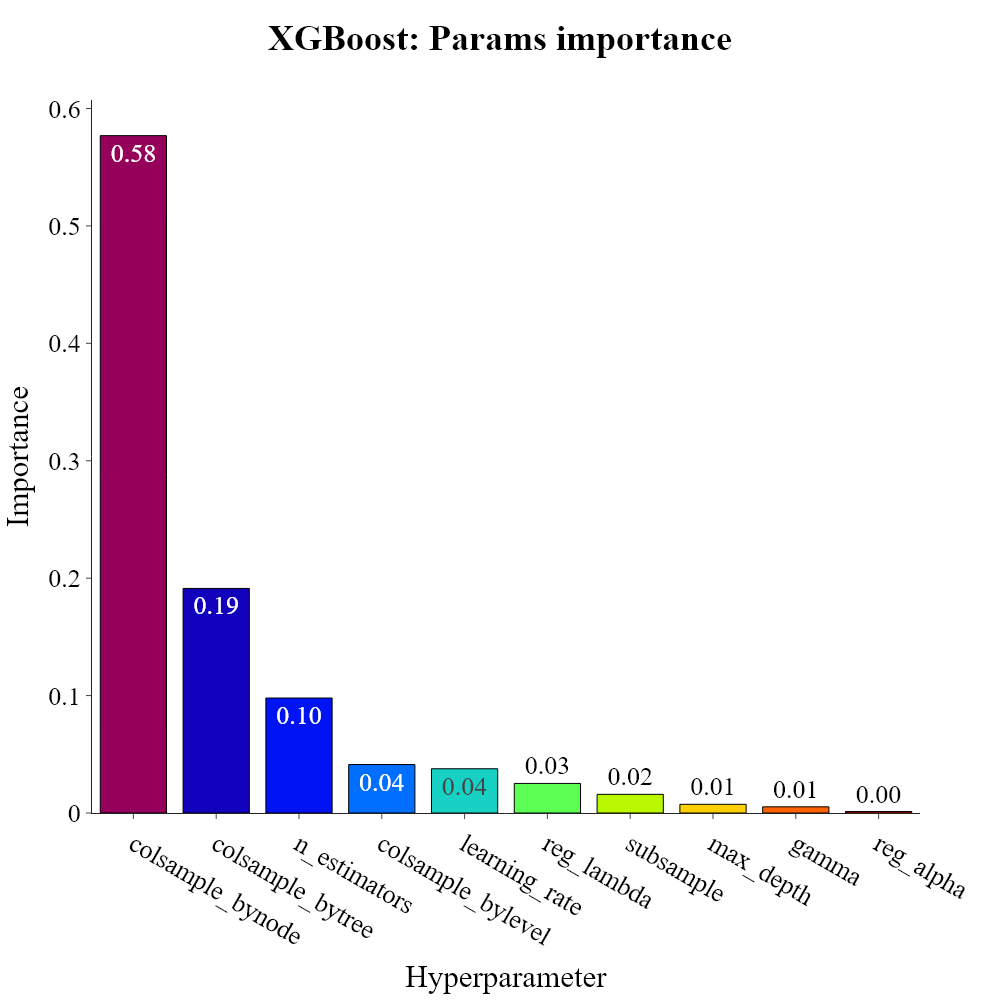

In [69]:
importances = optuna.importance.get_param_importances(study)
fig = go.Figure()
n_colors = len(importances)
colors = px.colors.sample_colorscale("rainbow", [n/(n_colors -1) for n in range(n_colors)])
fig.add_trace(go.Bar(x=list(importances.keys()), y=list(importances.values()), marker=dict(color=colors, line=dict(color='black', width=1), line_color='black'), text=[f"{v:.2f}" for v in list(importances.values())], textposition="auto"))
fig.update_layout(template="simple_white", width=1000, height=1000, title="<b>XGBoost: Params importance<b>", title_x=0.5, xaxis_title="Hyperparameter", yaxis_title=f"Importance", font=dict(family="Times New Roman",size=26,color="Black"), showlegend=False)
fig.show("png")

In [70]:
xgb_best_params = study.best_trial.params
model = XGBRegressor(**xgb_best_params, random_state=SEED, n_jobs=-1, objective='reg:squarederror', enable_categorical=True, tree_method='hist')
train_scores, validation_scores = perform_cv(train_data[independent_features], train_data[target_feature], model, cv=KFold(n_splits=5, shuffle=True, random_state=SEED), metric=root_mean_squared_error)
print(f"Train {compare_metric_name}: {np.mean(train_scores):.4f} +- {np.std(train_scores):.4f}")
print(f"Validation {compare_metric_name}: {np.mean(validation_scores):.4f} +- {np.std(validation_scores):.4f}")

Train RMSE: 12.0751 +- 0.0787
Validation RMSE: 13.8221 +- 0.2628


### Histogram-based Gradient Boosting

In [71]:
model = HistGradientBoostingRegressor()
cv = RandomSearchCV(
    algorithm=model,
    metric="rmse",
    cv=KFold(n_splits=5, shuffle=True, random_state=SEED),
    n_trials=N_TRIALS,
    seed=SEED
)

params_grid = {
    "random_state": ("constant", [SEED]),
    "loss": ("constant", ["squared_error"]),
    "categorical_features": ("constant", [categorical_features]),
    "learning_rate": ("float", [1e-3, 0.5]),
    "max_iter": ("int", [50, 1000]),
    "max_leaf_nodes": ("int", [10, 450]),
    "max_depth": ("int", [3, 30]),
    "min_samples_leaf": ("int", [10, 300]),
    "l2_regularization": ("float", [1e-3, 30]),
    "max_features": ("float", [0.3, 1]),
}
study = cv.tune(
    train_data[independent_features],
    train_data[target_feature],
    params_grid
)

[I 2025-04-28 22:42:12,420] A new study created in memory with name: Optuna tuning
[I 2025-04-28 22:42:15,391] Trial 0 finished with value: 13.770013414996859 and parameters: {'learning_rate': 0.006241543527823154, 'max_iter': 554, 'max_leaf_nodes': 94, 'max_depth': 4, 'min_samples_leaf': 239, 'l2_regularization': 0.8679301209323235, 'max_features': 0.6463494460474463}. Best is trial 0 with value: 13.770013414996859.
[I 2025-04-28 22:42:19,571] Trial 1 finished with value: 14.10016389174557 and parameters: {'learning_rate': 0.03577131821038233, 'max_iter': 87, 'max_leaf_nodes': 167, 'max_depth': 29, 'min_samples_leaf': 27, 'l2_regularization': 7.386203463828322, 'max_features': 0.8626563515456908}. Best is trial 0 with value: 13.770013414996859.
[I 2025-04-28 22:42:28,251] Trial 2 finished with value: 16.855947456199715 and parameters: {'learning_rate': 0.0013745804660383028, 'max_iter': 670, 'max_leaf_nodes': 253, 'max_depth': 19, 'min_samples_leaf': 150, 'l2_regularization': 0.018491

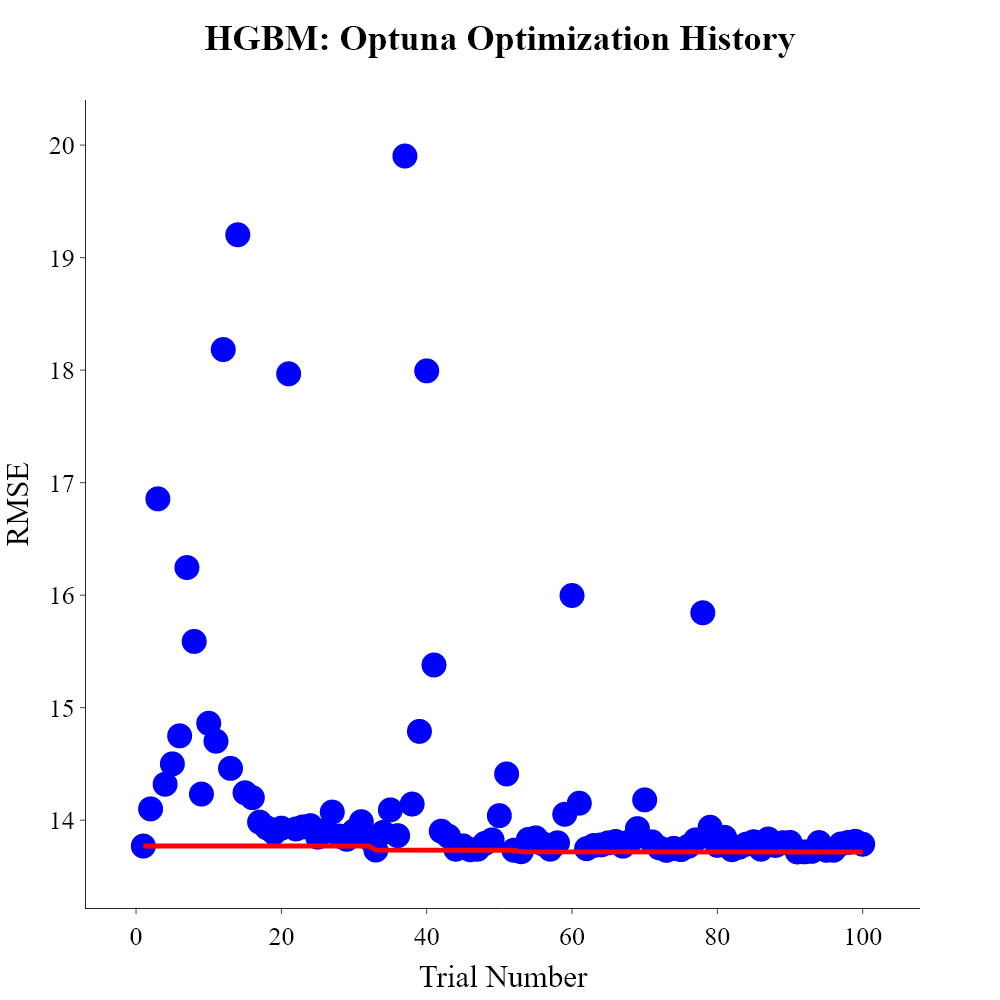

In [72]:
scores = study.trials_dataframe()
fig = go.Figure()
scores.index = scores.index + 1
fig.add_trace(go.Scatter(x=scores.index, y=scores["value"], mode="markers", name="Trial Score", marker=dict(size=25, color="blue"), showlegend=False))
minimum_scores = []
for i in range(len(scores)):
    minimum_scores.append(scores.loc[:i+1, "value"].min())
fig.add_trace(go.Scatter(x=scores.index, y=minimum_scores, mode="lines", name="Minimum Score", line=dict(color="red", width=5), showlegend=False))
fig.update_layout(template="simple_white", width=1000, height=1000, title="<b>HGBM: Optuna Optimization History<b>", title_x=0.5, xaxis_title="Trial Number", yaxis_title=compare_metric_name, font=dict(family="Times New Roman",size=26,color="Black"), showlegend=False)
fig.show("png")

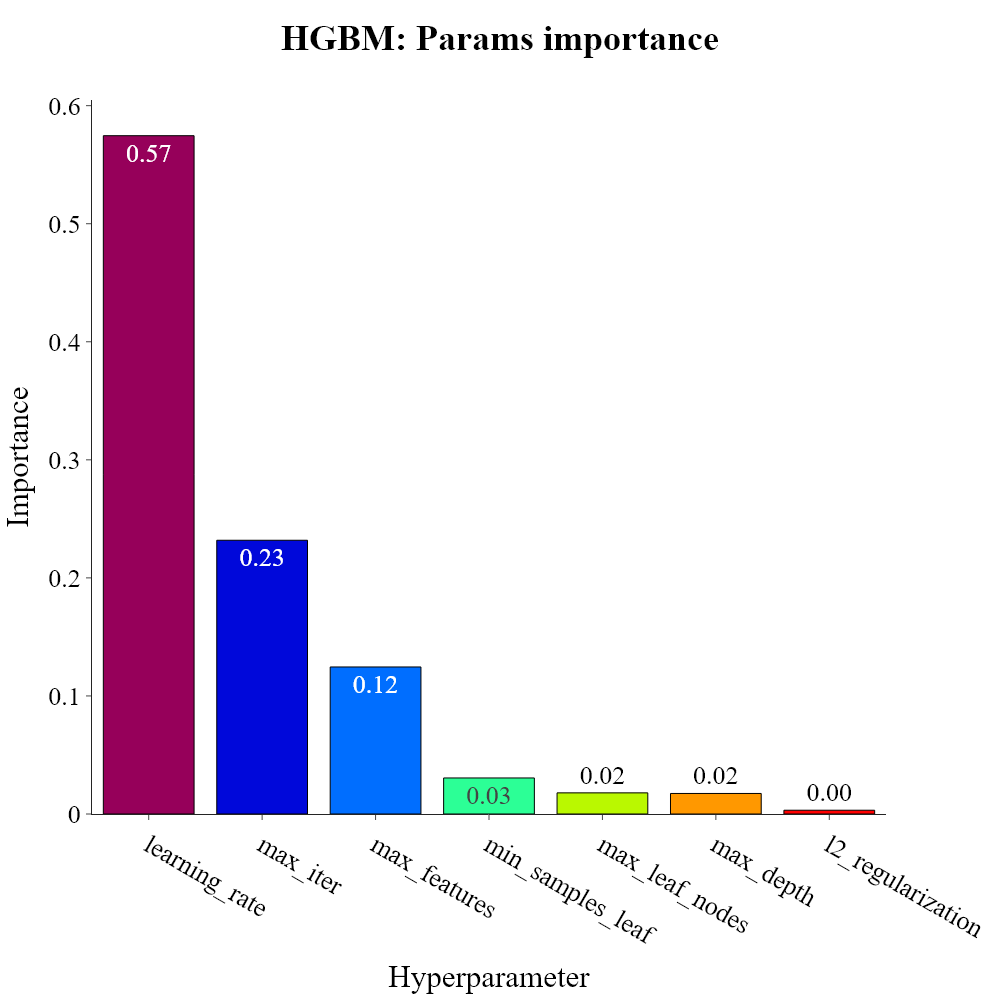

In [73]:
importances = optuna.importance.get_param_importances(study)
fig = go.Figure()
n_colors = len(importances)
colors = px.colors.sample_colorscale("rainbow", [n/(n_colors -1) for n in range(n_colors)])
fig.add_trace(go.Bar(x=list(importances.keys()), y=list(importances.values()), marker=dict(color=colors, line=dict(color='black', width=1), line_color='black'), text=[f"{v:.2f}" for v in list(importances.values())], textposition="auto"))
fig.update_layout(template="simple_white", width=1000, height=1000, title="<b>HGBM: Params importance<b>", title_x=0.5, xaxis_title="Hyperparameter", yaxis_title=f"Importance", font=dict(family="Times New Roman",size=26,color="Black"), showlegend=False)
fig.show("png")

In [74]:
hgbm_best_params = study.best_trial.params
model = HistGradientBoostingRegressor(**hgbm_best_params, random_state=SEED, categorical_features=categorical_features)
train_scores, validation_scores = perform_cv(train_data[independent_features], train_data[target_feature], model, cv=KFold(n_splits=5, shuffle=True, random_state=SEED), metric=root_mean_squared_error)
print(f"Train {compare_metric_name}: {np.mean(train_scores):.4f} +- {np.std(train_scores):.4f}")
print(f"Validation {compare_metric_name}: {np.mean(validation_scores):.4f} +- {np.std(validation_scores):.4f}")

Train RMSE: 13.1541 +- 0.0785
Validation RMSE: 13.7175 +- 0.2367


## Stacking

In [75]:
estimators = [
    ('lightgbm', LGBMRegressor(**lgbm_best_params, random_state=SEED, n_jobs=-1, verbose=0, objective='regression', metric=compare_metric_name, linear_tree=True)),
    ('xgboost', XGBRegressor(**xgb_best_params, random_state=SEED, n_jobs=-1, verbose=0, objective='reg:squarederror', enable_categorical=True, tree_method='hist')),
    ('hist_gradient_boosting', HistGradientBoostingRegressor(**hgbm_best_params, random_state=SEED, categorical_features=categorical_features)),
]
stacking_model = StackingRegressor(estimators=estimators, final_estimator=ElasticNetCV(random_state=SEED), cv=KFold(n_splits=5, shuffle=True, random_state=SEED), n_jobs=-1)
train_scores, validation_scores = perform_cv(train_data[independent_features], train_data[target_feature], stacking_model, cv=KFold(n_splits=5, shuffle=True, random_state=SEED), metric=root_mean_squared_error)
print(f"Train {compare_metric_name}: {np.mean(train_scores):.4f} +- {np.std(train_scores):.4f}")
print(f"Validation {compare_metric_name}: {np.mean(validation_scores):.4f} +- {np.std(validation_scores):.4f}")

Train RMSE: 12.9835 +- 0.1054
Validation RMSE: 13.7050 +- 0.2423


In [76]:
train_data_temp, test_data_temp = train_test_split(train_data, test_size=0.2, random_state=SEED, shuffle=True)
stacking_model.fit(train_data_temp[independent_features], train_data_temp[target_feature])

StackingRegressor(cv=KFold(n_splits=5, random_state=17, shuffle=True),
                  estimators=[('lightgbm',
                               LGBMRegressor(colsample_bytree=0.8262658399224875,
                                             learning_rate=0.028669294845544136,
                                             linear_lambda=0.06074408996684257,
                                             linear_tree=True, max_depth=3,
                                             metric='RMSE',
                                             min_child_samples=57,
                                             n_estimators=247, n_jobs=-1,
                                             num_leaves=114,
                                             objective='regression',
                                             random_sta...
                                                                                   'Publication_Time',
                                                                                   'Episode_Sentiment',
                                                                                   'Episode_Length_minutes_Imputed',
                                                                                   'is_weekend',
                                                                                   'Guest_Popularity_percentage_Imputed'],
                                                             l2_regularization=8.8492423028697,
                                                             learning_rate=0.02024148829544393,
                                                             max_depth=3,
                                                             max_features=0.44340155425044353,
                                                             max_iter=439,
                                                             max_leaf_nodes=370,
                                                             min_samples_leaf=275,
                                                             random_state=17))],
                  final_estimator=ElasticNetCV(random_state=17), n_jobs=-1)

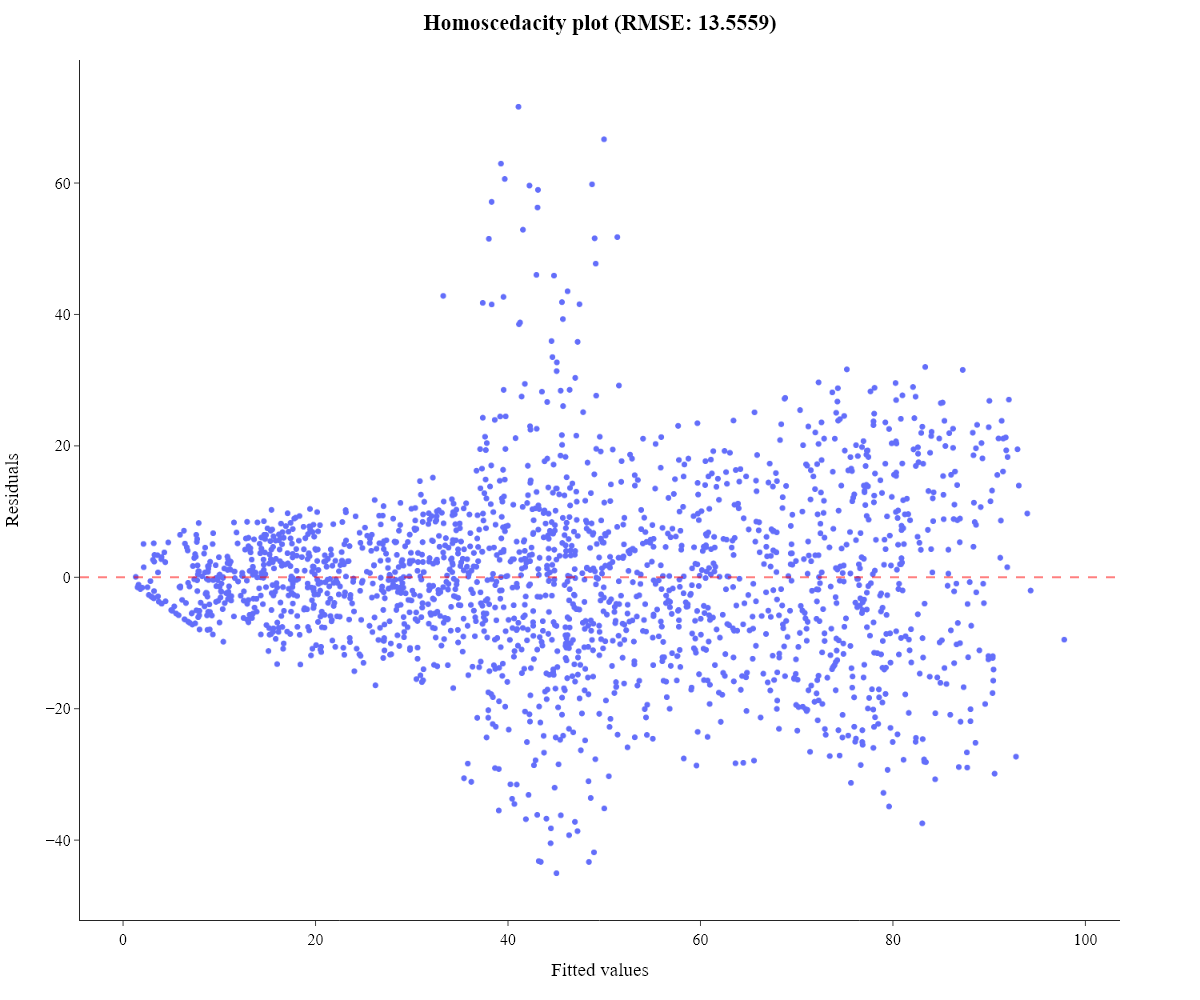

In [77]:
y_test = test_data_temp[target_feature]
y_test_pred = stacking_model.predict(test_data_temp[independent_features])

def homoscedacity_plot(y_true, y_pred, metric="RMSE"):
    metrics = { "MSE": mean_squared_error(y_true, y_pred),
            "RMSE": root_mean_squared_error(y_true, y_pred),
            "MAE": mean_absolute_error(y_true, y_pred)}
    if metric not in metrics:
        raise ValueError('Unsupported metric: {}'.format(metric))
    eval_metric = np.round(metrics[metric], 5)
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    residuals = y_true - y_pred
    fig = px.scatter(x=y_pred, y=residuals, labels={"x": "Fitted values",  "y": "Residuals"})
    fig.add_shape(type="line", line_color="red", line_width=2, opacity=0.5, line_dash="dash",x0=0, x1=1, xref="paper", y0=0, y1=0, yref="y")
    fig.update_layout(template="simple_white", width=1200, height=1000, title=f"<b>Homoscedacity plot ({metric.upper()}: {eval_metric:.4f})<b>", title_x=0.5, xaxis_title="Fitted values", yaxis_title="Residuals", font=dict(family="Times New Roman",size=16,color="Black"))
    fig.show("png")

plots.homoscedacity_plot(y_test, y_test_pred, metric="RMSE")

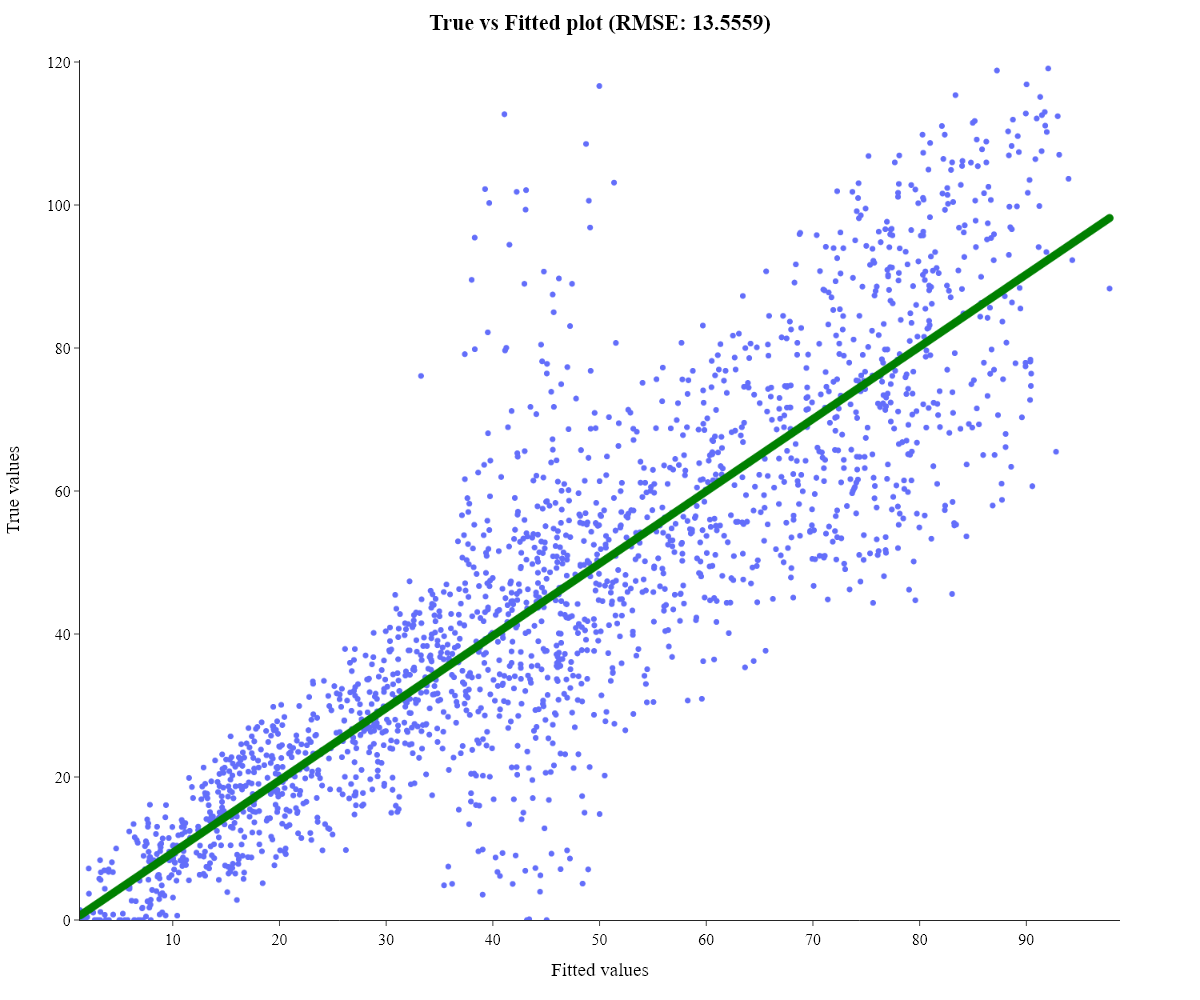

In [78]:
plots.true_vs_fitted_plot(y_test, y_test_pred, metric="RMSE")

# Final submission

In [79]:
estimators = [
    ('lightgbm', LGBMRegressor(**lgbm_best_params, random_state=SEED, n_jobs=-1, verbose=0, objective='regression', metric=compare_metric_name, linear_tree=True)),
    ('xgboost', XGBRegressor(**xgb_best_params, random_state=SEED, n_jobs=-1, verbose=0, objective='reg:squarederror', enable_categorical=True, tree_method='hist')),
    ('hist_gradient_boosting', HistGradientBoostingRegressor(**hgbm_best_params, random_state=SEED, categorical_features=categorical_features)),
]
final_model = StackingRegressor(estimators=estimators, final_estimator=ElasticNetCV(random_state=SEED), cv=KFold(n_splits=5, shuffle=True, random_state=SEED), n_jobs=-1)
final_model.fit(train_data.drop(target_feature, axis=1), train_data[target_feature])
submission = pd.read_csv("input/sample_submission.csv")
submission[target_feature] = final_model.predict(test_data)
#submission.to_csv("submission.csv", index=False)
submission.head()

,id,Listening_Time_minutes
0,750000,57.080116
1,750001,18.875066
2,750002,45.559577
3,750003,86.089914
4,750004,50.325595
